**Структура ноутбука:**
1. Импорты
2. Функции: вспомогательные функции для EDA, woe-биннинга и визуализации
3. Предобработка данных - основная таблица + агрегация вспомогательных
4. EDA - оценка значимости признаков и подробный разбор ключевых
5. Обучение и валидация — log_reg на woe-признаках + LightGBM на сырых,
   подбор гиперпараметров, кросс-валидация, блендинг
6. Интерпретируемость результатов — коэффициенты, SHAP, сверка с IV, PSI
7. Предсказание на test — финальное обучение на всем train и сборка submission.csv

В выполнении соревнования я ориентировался на открытые лучшие решения из соревнования Kaggle_Home_Credit:

- [kozodoi/Kaggle_Home_Credit](https://github.com/kozodoi/Kaggle_Home_Credit)
- [oskird/Kaggle-Home-Credit-Default-Risk-Solution](https://github.com/oskird/Kaggle-Home-Credit-Default-Risk-Solution)
- [NoxMoon/home-credit-default-risk](https://github.com/NoxMoon/home-credit-default-risk)

# 1. Импорты

In [89]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV
from scipy.stats import chi2_contingency

pd.set_option('display.width', 150)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")
previous_loans = pd.read_csv(DATA_DIR / "previous_loans.csv")
bureau = pd.read_csv(DATA_DIR / "bureau.csv")

# 2. Функции

In [90]:
def leakage_check(df, col, target='target'):
     """
     сравнивает распределение значений признака и долю nan-значений между
     группами target=0 и target=1. Использую ее для проверки на утечку данных.
     Если распределение слишком чисто разделяет классы
     (квартили не пересекаются, доля пропусков резко отличается),
     это может означать, что признак содержит информацию, недоступную
     на момент подачи заявки, а не реальную связь с риском
     """
     missing_rate = df.groupby(target)[col].apply(lambda x: x.isna().mean())

     if pd.api.types.is_numeric_dtype(df[col]):
          info = df.groupby(target)[col].describe()
     else: 
          info = df.groupby(target)[col].value_counts(normalize=True)

     return info, missing_rate

In [91]:
from scipy.stats import chi2_contingency, ttest_ind

def chi2(column1, column2, data, verbose=True):
    """
    Функция считает хи-квадрат и p-value для двух категориальных признаков, 
    а также рассчитывает коэффицент Крамера (Cramer's V) 
    и ожидаемый уровень V при чистом шуме (H0)
    """
    contingency = pd.crosstab(data[column1], data[column2], dropna=False)
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    noise_floor_v = np.sqrt(dof / n)

    if verbose:
        print(f"p-value = {p_value:.4f}, Cramer's V = {cramers_v:.4f}")
        print(f"ожидаемый уровень V при чистом шуме (H0) = {noise_floor_v:.4f}")
        print(f"expected.min() = {expected.min():.2f}")

    return p_value, cramers_v  


def ttest(column1, column2, data, verbose=True):
    """
    Функция считает t-test и p-value для непрерывного и категориального признака (target), 
    а также рассчитывает n^2 (eta squared) и количество наблюдений в каждой группе
    """
    group1 = data[data[column2] == 0][column1]
    group2 = data[data[column2] == 1][column1]
    t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
    n1, n2 = group1.notna().sum(), group2.notna().sum()
    df = n1 + n2 - 2
    eta_squared = t_stat**2 / (t_stat**2 + df)

    if verbose:
        print(f"p-value = {p_value:.5f}")
        print(f"η² (eta squared) = {eta_squared:.4f}")

    return p_value, eta_squared


In [92]:
def calc_woe_iv(df, feature, target, n_start_bins=10, min_bin_frac=0.05, p_merge_threshold=0.05, categorical_feature=None):
    """
    Считает woe (weight of evidence) и iv (information value) признака относительно таргета.

    Для числовых признаков сначала режет на n_start_bins бинов по квантилям,
    затем объединяет соседние бины, если разница в bad_rate между ними
    статистически незначима (chi2, p > p_merge_threshold) или бин слишком мал
    (< min_bin_frac от выборки). Так итоговые бины получаются крупнее и стабильнее.
    Для категориальных признаков бином считается сама категория.
    Пропуски идут отдельным бином 'Missing'.

    categorical_feature позволяет явно указать тип признака вместо автоопределения
    по dtype, это оказалось важно для бинарных числовых флагов (например has_bureau),
    которые по dtype выглядят как числовые, но по смыслу являются категориальными
    """
    x = df[feature]
    y = df[target]

    if categorical_feature is None: 
        categorical_feature = not pd.api.types.is_numeric_dtype(x)

    is_numeric = not categorical_feature

    if is_numeric:
        # стартовое разбиение на бины
        bins = pd.qcut(x, q=n_start_bins, duplicates='drop')

        # дообавляю категорию для пропусков, если они есть и заполняю ее
        bins = bins.cat.add_categories(['Missing']).fillna('Missing')

        # сортировка бингов в порядке возрастания
        order = sorted([c for c in bins.cat.categories if c != 'Missing'], key=lambda iv: iv.left)

        # приклеиваю missing в конец списка, так как у него нет числовой позиции
        if 'Missing' in bins.unique():
            order += ['Missing']
    else:
        # случай категориального признака, заменяю пропуски на missing
        bins = x.astype('object').fillna('Missing')
        order = list(pd.unique(bins))

    work = pd.DataFrame({'bin': bins, 'target': y})

    def bin_table(order):
        g = work.groupby('bin', observed=True)['target'].agg(n='size', bad='sum')
        g['good'] = g['n'] - g['bad']
        return g.reindex(order)

    n_total = len(work)
    min_n = n_total * min_bin_frac

    while len(order) > 2:
        table = bin_table(order)


        best_p, best_i = -1, None
        for i in range(len(order) - 1):
            ct = table.loc[[order[i], order[i+1]], ['good', 'bad']].values
            if ct.sum() == 0:
                continue
            _, p, _, _ = chi2_contingency(ct)
            if p > best_p:
                best_p, best_i = p, i

        smallest_i = table['n'].values.argmin()
        need_merge_small = table['n'].iloc[smallest_i] < min_n

        if best_p > p_merge_threshold or need_merge_small:
            i = best_i if best_p > p_merge_threshold else max(min(smallest_i, len(order) - 2), 0)
            merged = f"{order[i]} + {order[i+1]}" if not is_numeric else order[i]
            work['bin'] = work['bin'].replace({order[i]: merged, order[i+1]: merged})
            order = order[:i] + [merged] + order[i+2:]
        else:
            break

    g = bin_table(order)
    total_good, total_bad = g['good'].sum(), g['bad'].sum()
    g['bad_rate'] = g['bad'] / g['n']
    g['dist_good'] = (g['good'] / total_good).replace(0, 1e-6)
    g['dist_bad'] = (g['bad'] / total_bad).replace(0, 1e-6)
    g['woe'] = np.log(g['dist_good'] / g['dist_bad'])
    g['iv_bin'] = (g['dist_good'] - g['dist_bad']) * g['woe']

    return g[['n', 'bad', 'bad_rate', 'woe', 'iv_bin']], g['iv_bin'].sum()


def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    v = np.sqrt((chi2 / n) / k) if k > 0 else np.nan
    return v, p

In [93]:
def plot_distribution(data, x, max_unique_for_bar=15):
    """
    Функция строит гистограмму распределения признака x
    """
    fig, ax = plt.subplots(figsize=(6, 4))
    # гистограмма для нерпрерывных признаков
    if pd.api.types.is_numeric_dtype(data[x]) and data[x].nunique() > max_unique_for_bar:
        ax.hist(data[x].dropna(), bins=30, color='#4C72B0')
    # столбчатая диаграмма для категориальных признаков
    else:
        if pd.api.types.is_numeric_dtype(data[x]):
            vc = data[x].value_counts().sort_index()  
            vc.index = vc.index.astype(str)
            n_missing = data[x].isna().sum()
            if n_missing:
                vc['Missing'] = n_missing               
        else:
            vc = data[x].fillna('Missing').value_counts()
        vc.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Распределение {x}')
    plt.tight_layout()
    plt.show()


def visualization(woe_table, x, target):
    """
    Фукнкция строт два графика: количество наблюдений по бинам
    и долю target=1 по бинам. Бины берутся из таблицы woe_table
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels = [str(i) for i in woe_table.index]

    axes[0].bar(labels, woe_table['n'], color="#3B5988")
    axes[0].set_title(f'Кол-во наблюдений по бинам {x}')
    axes[0].tick_params(axis='x', rotation=45, labelsize=8)

    axes[1].bar(labels, woe_table['bad_rate'], color="#DD8452")
    for i, n in enumerate(woe_table['n']):
        axes[1].text(i, woe_table['bad_rate'].iloc[i] + 0.01, f'n={n}', ha='center', fontsize=8)
    axes[1].set_title(f'Доля {target}=1 по бинам {x}')
    axes[1].set_ylabel(f'доля {target}=1')
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)

    plt.tight_layout()
    plt.show()

In [94]:
def feature_significance_table(features, target, data, categorical_features=None):
    """
    Функция строит таблицу с p-value, силой эффекта (Cramer's V/eta squared) и IV
    для списка признаков — для быстрой оценки значимости всех фичей разом.
    """
    categorical_features = set(categorical_features or [])
    results = []
    for col in features:
        kind = 'categorical' if col in categorical_features else 'continuous'

        if kind == 'continuous':
            p, effect = ttest(col, target, data, verbose=False)
            test_name = 'ttest'
        else:
            p, effect = chi2(col, target, data, verbose=False)
            test_name = 'chi2'

        woe_table, iv = calc_woe_iv(data, col, target, categorical_feature=(col in categorical_features))
        results.append({'feature': col, 'kind': kind, 'test': test_name, 'p_value': p, 'effect': effect, 'IV': iv})

    return pd.DataFrame(results).sort_values('IV', ascending=False).reset_index(drop=True).round(4)

In [95]:
def fit_woe(df, feature, target, is_categorical, n_bins=10, smoothing=0.5):
    """
    Считает woe-биннинг признака на df и возвращает готовые правила
    (границы бинов + woe каждого бина) для применения через transform_woe.
    """
    x = df[feature]
    y = df[target]

    if is_categorical:
        bin_of = x.astype('object').fillna('Missing')
        edges = None
    else:
        _, edges = pd.qcut(x, q=n_bins, duplicates='drop', retbins=True)
        edges[0], edges[-1] = -np.inf, np.inf
        bin_of = pd.cut(x, bins=edges).astype('object').fillna('Missing')

    table = pd.DataFrame({'bin': bin_of, 'target': y})
    agg = table.groupby('bin', observed=True)['target'].agg(n='size', bad='sum')
    agg['good'] = agg['n'] - agg['bad']

    total_good, total_bad = agg['good'].sum(), agg['bad'].sum()
    dist_good = (agg['good'] + smoothing) / (total_good + smoothing * len(agg))
    dist_bad = (agg['bad'] + smoothing) / (total_bad + smoothing * len(agg))
    woe = np.log(dist_good / dist_bad)

    return {'is_categorical': is_categorical, 'edges': edges,
            'woe_map': woe.to_dict(), 'default_woe': 0.0}


def transform_woe(df, feature, fitted):
    """
    Применяет уже готовые правила из fit_woe к df, заменяя значения признака на woe
    """
    x = df[feature]
    if fitted['is_categorical']:
        bin_of = x.astype('object').fillna('Missing')
    else:
        bin_of = pd.cut(x, bins=fitted['edges']).astype('object').fillna('Missing')
    return bin_of.map(fitted['woe_map']).fillna(fitted['default_woe'])

# 3. Предобработка данных

## 3.1. Работа с основной таблицей


In [96]:
# проверяю размеры таблиц 

print("train:", train.shape, train.shape)
print("test:", test.shape, test.shape)
print("buro:", bureau.shape)
print("transactions:", transactions.shape)
print("previous_loans:", previous_loans.shape)


train: (6488, 25) (6488, 25)
test: (2520, 24) (2520, 24)
buro: (24689, 8)
transactions: (353300, 6)
previous_loans: (12762, 7)


In [97]:
# удаляю дубли строк в train, в test их нет

print(f'дубликатов в train = {train.duplicated().sum()}')
print(f'дубликатов в test = {test.duplicated().sum()}')

train = train.drop_duplicates().reset_index(drop=True)

дубликатов в train = 8
дубликатов в test = 0


Feature engineering основной таблицы

In [98]:
train.columns

Index(['application_id', 'client_id', 'employment_type', 'hash_id', 'region_coefficient_extended', 'age', 'incoming_amount',
       'internal_decision_code', 'monthly_income', 'application_date', 'education', 'requested_product', 'channel', 'loan_amount',
       'marketing_segment', 'post_loan_collection_score', 'region_coefficient', 'region', 'interest_rate', 'months_at_job', 'dependents',
       'days_until_first_overdue', 'loan_term_months', 'siberia_northern_score', 'target'],
      dtype='str')

In [99]:
# утечка: признак фактически кодирует факт просрочки

leakage_check(train, 'days_until_first_overdue') 
train = train.drop('days_until_first_overdue', axis=1)
test = test.drop('days_until_first_overdue', axis=1)

In [100]:
# утечка: оценка коллекторов считается после выдачи займа, недоступна на момент заявки

leakage_check(train, 'post_loan_collection_score') 
train = train.drop('post_loan_collection_score', axis=1)
test = test.drop('post_loan_collection_score', axis=1)

In [101]:
# утечка: неизвестно, когда признак фиксируется

leakage_check(train, 'internal_decision_code')
train = train.drop('internal_decision_code', axis=1)
test = test.drop('internal_decision_code', axis=1)

# остальные колонки проверены на проверены аналогично, утечек не обнаружил

In [102]:
# удаляю hash_id, дублирует client_id

train.groupby('hash_id')['client_id'].nunique().value_counts()
train = train.drop('hash_id', axis=1)
test = test.drop('hash_id', axis=1)

# удаляю константу, не несет сигнала для модели
train['region_coefficient'].value_counts(dropna=False)
train = train.drop('region_coefficient', axis=1)

In [103]:
# проверка различия monthly_income и incoming_amount

both = train['monthly_income'].notna() & train['incoming_amount'].notna()
print('оба заполнены:', both.sum())
print('из них совпадают:', (train.loc[both, 'monthly_income'] == train.loc[both, 'incoming_amount']).mean())

# там, где оба значения не nan, они полностью совпадают
# объединение признаков
train['income'] = train['monthly_income'].fillna(train['incoming_amount'])
test['income'] = test['monthly_income'].fillna(test['incoming_amount'])

оба заполнены: 5637
из них совпадают: 1.0


In [104]:
# денежные показатели обычно ассиметричны, устраняю симметрию логарифмированием

print(f"ассиметрия income: {train['income'].skew()}")
print(f"ассиметрия loan_amount: {train['loan_amount'].skew()}")

train['log_income'] = np.log(train['income'] + 1)
test['log_income'] = np.log(test['income'] + 1)

train['log_loan_amount'] = np.log1p(train['loan_amount'])
test['log_loan_amount'] = np.log1p(test['loan_amount'])  

ассиметрия income: 1.809429878655907
ассиметрия loan_amount: 2.0829455188681103


In [105]:
# создание новых признаков

# платежеспособность
train['loan_by_income'] = train['loan_amount'] / train['income']
test['loan_by_income'] = test['loan_amount'] / test['income']

# доход на члена семьи
train['income_per_person'] = (train['income'] / (train['dependents'] + 1))
test['income_per_person'] = (test['income'] / (test['dependents'] + 1))

## 3.2 Работа с дополнительными таблицами

Таблицы bureau, previous_loans, transactions нельзя просто смержить по client_id, потому что каждому client_id в этих таблицах может соответствовать несколько строк. Данные можно объединить, предварительно сгруппировав их по client_id и вычислив различные показатели (min, max, mean...)

In [106]:
transactions.head()

,client_id,application_id,transaction_date,transaction_category,amount,merchant_risk_level
0,1,100001,2025-10-22,transfer,-1538.95,5.0
1,1,100001,2025-07-10,cash_withdrawal,-1460.46,1.0
2,1,100001,2025-11-01,utilities,-988.50,2.0
3,1,100001,2025-10-10,salary,8578.27,3.0
4,1,100001,2025-12-24,entertainment,-2015.69,2.0


Feature engineering transactions

In [107]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# агрегация по числовым признакам
transactions_agg = transactions.groupby('client_id').agg(
    # счет, сумма, среднее, медиана, отклонение всех транзакций
    transactions_count = ('amount', 'count'),
    transactions_amount_sum = ('amount', 'sum'),
    transactions_amount_mean = ('amount', 'mean'),
    transactions_amount_median = ('amount', 'median'),
    transactions_amount_std = ('amount', 'std' ),

    # среднее риска транзакции
    transactions_risk_mean = ('merchant_risk_level', 'mean')

).reset_index()

# считаю долю каждой категории транзакций у каждого клиента 
transactions_category = pd.crosstab(transactions['client_id'], transactions['transaction_category'], normalize='index').reset_index()

# объединяю доли категорий с созданными числовыми признаками
transactions_agg = transactions_agg.merge(transactions_category, on='client_id', how='left')

# временной признак: сколько дней назад была последняя транзакция до подачи заявки

dates = pd.concat([
    train[['application_id', 'application_date']],
    test[['application_id', 'application_date']],
])
dates['application_date'] = pd.to_datetime(dates['application_date'])

transactions_with_date = transactions.merge(dates, on='application_id', how='inner')
transactions_with_date['days_before_application'] = (
    transactions_with_date['application_date'] - transactions_with_date['transaction_date']
).dt.days

recency = transactions_with_date.groupby('client_id')['days_before_application'].min().rename('days_since_last_transactions').reset_index()
transactions_agg = transactions_agg.merge(recency, on='client_id', how='left')

# доходные и расходные признаки

income = transactions.groupby('client_id')['amount'].apply(lambda x: x[x > 0].sum())
expenses = transactions.groupby('client_id')['amount'].apply(lambda x: abs(x[x < 0].sum()))

# отсутствие доходов или расходов может иметь значение для оценки 
no_income = (income == 0).rename('no_income_transactions').astype(int).reset_index()
# no_expenses нет

# денежный поток
cash_flow = (income / expenses).replace([np.inf, -np.inf], np.nan).rename('cash_flow').reset_index()


In [108]:
# мержу все новые признаки в transactions
transactions_agg = transactions_agg.merge(cash_flow, on='client_id', how='left')
transactions_agg = transactions_agg.merge(no_income, on='client_id', how='left')

# мержу transactions в train и test
train = train.merge(transactions_agg, on='client_id', how='left')
test = test.merge(transactions_agg, on='client_id', how='left')

Далее идет агрегация транзакций клиентов по периодам 30-60-90 дней.
Несмотря на статистическую значимость признаков, на обучении они немного снижают roc_auc каждой модели, поэтому в финальный ноутбук их не включаю

In [109]:

# mask_30_days = (transactions_with_date['days_before_application'] > 0) & (transactions_with_date['days_before_application'] <= 30)
# mask_60_days = (transactions_with_date['days_before_application'] > 30) & (transactions_with_date['days_before_application'] <= 60)
# mask_90_days = (transactions_with_date['days_before_application'] > 60) & (transactions_with_date['days_before_application'] <= 90)

# transactions_30_days = transactions_with_date[mask_30_days]
# transactions_60_days = transactions_with_date[mask_60_days]
# transactions_90_days = transactions_with_date[mask_90_days]

# transactions_30_days = transactions_30_days.groupby('client_id').agg(
#     transactions_amount_30_days_sum = ('amount', 'sum'),
#     transactions_amount_30_days_mean = ('amount', 'mean'),
#     transactions_amount_30_days_std = ('amount', 'std'),

#     transactions_30_days_count = ('amount', 'count'),

#     transactions_risk_30_days_mean = ('merchant_risk_level', 'mean')
# ).reset_index()

# transactions_60_days = transactions_60_days.groupby('client_id').agg(
#     transactions_amount_60_days_sum = ('amount', 'sum'),
#     transactions_amount_60_days_mean = ('amount', 'mean'),
#     transactions_amount_60_days_std = ('amount', 'std'),

#     transactions_60_days_count = ('amount', 'count'),

#     transactions_risk_60_days_mean = ('merchant_risk_level', 'mean')
# ).reset_index()

# transactions_90_days = transactions_90_days.groupby('client_id').agg(
#     transactions_amount_90_days_sum = ('amount', 'sum'),
#     transactions_amount_90_days_mean = ('amount', 'mean'),
#     transactions_amount_90_days_std = ('amount', 'std'),

#     transactions_90_days_count = ('amount', 'count'),

#     transactions_risk_90_days_mean = ('merchant_risk_level', 'mean')
# ).reset_index()

Feature engineering bureau

In [110]:
bureau.head()

,client_id,bureau_account_id,account_type,opened_days_ago,credit_limit,current_balance,max_dpd_last_12m,bureau_status
0,1,B1_0,credit_card,2410.0,20474.70,5760.10,0.0,active
1,2,B2_1,NaN,2983.0,61748.02,47175.10,1.0,active
2,3,B3_2,auto,943.0,93069.06,40725.25,15.0,active
3,3,B3_3,mortgage,2355.0,173852.51,57974.36,7.0,closed
4,3,B3_4,credit_card,302.0,24037.79,7801.91,1.0,closed


In [111]:
bureau_agg = bureau.groupby('client_id').agg(
    # счет счетов
    bureau_account_id_count = ('bureau_account_id', 'count'),

    #сумма, среднее, максимум, минимум, отклонение кредитного лимита
    credit_limit_sum = ('credit_limit', 'sum'),
    credit_limit_mean = ('credit_limit', 'mean'),
    credit_limit_max = ('credit_limit', 'max'),
    credit_limit_min = ('credit_limit', 'min'),
    credit_limit_std = ('credit_limit', 'std'),

    # сумма, среднее, максимум, минимум баланса
    current_balance_sum = ('current_balance', 'sum'),
    current_balance_mean = ('current_balance', 'mean'),
    current_balance_max = ('current_balance', 'max'),
    current_balance_min = ('current_balance', 'min'),

    # сумма, среднее, максимум, минимум просрочки 
    max_dpd_last_12m_max = ('max_dpd_last_12m', 'max'), 
    max_dpd_last_12m_min = ('max_dpd_last_12m', 'min'), 
    max_dpd_last_12m_mean = ('max_dpd_last_12m', 'mean'),
    max_dpd_last_12m_sum = ('max_dpd_last_12m', 'sum'),
    
).reset_index()

# доля активных кредитов
bureau_active_status = bureau.groupby('client_id')['bureau_status'].apply(
    lambda x: (x == 'active').mean()
).rename('bureau_active_status').reset_index()

# считаю долю использованного кредитного лимита для каждого счета
bureau['utilization'] = bureau['current_balance'] / bureau['credit_limit']

# максимум и минимум доля использованного лимита по всем счетам
utilization_agg = bureau.groupby('client_id').agg(
    utilization_max = ('utilization', 'max'), 
    utilization_mean = ('utilization','mean')
).reset_index()

# считаю долю общего использованного кредитного лимита
bureau_agg['utilization_gen'] = (bureau_agg['current_balance_sum'] / bureau_agg['credit_limit_sum']).replace([np.inf, -np.inf], np.nan)

# доля кредитов по типам
bureau_account_type = pd.crosstab(bureau['client_id'], bureau['account_type'], normalize='index').reset_index()

In [112]:
print(f"кол-во client_id в bureau: {bureau['client_id'].nunique()}")
print(f"кол-во client_id в train и test: {train['client_id'].nunique() + test['client_id'].nunique()}")
print(f"у {train['client_id'].nunique() + test['client_id'].nunique() - bureau['client_id'].nunique()} клиентов нет информации о внешней кредитной истории")

# дабавляю бинарный флаг: имеет ли клиент внешние долги
train['has_bureau'] = train['client_id'].isin(bureau['client_id']).astype(int)
test['has_bureau'] = test['client_id'].isin(bureau['client_id']).astype(int)

кол-во client_id в bureau: 8542
кол-во client_id в train и test: 9000
у 458 клиентов нет информации о внешней кредитной истории


In [113]:
# merge новых признаков с агрегированным bureau
bureau_agg = bureau_agg.merge(bureau_active_status, on='client_id', how='left')
bureau_agg = bureau_agg.merge(bureau_account_type, on='client_id', how='left')
bureau_agg = bureau_agg.merge(utilization_agg, on='client_id', how='left')

# merge агрегированного bureau с train и test
train = train.merge(bureau_agg, on='client_id', how='left')
test = test.merge(bureau_agg, on='client_id', how='left')

Feature engineering previous_loans

In [114]:
loans_agg = previous_loans.groupby('client_id').agg(
    # количество прошлых займов
    previous_loan_count = ('previous_loan_id', 'count'),

    # сумма, среднее, минимум, максимум прошлых займов
    previous_amount_sum = ('previous_amount', 'sum'),
    previous_amount_mean = ('previous_amount', 'mean'),
    previous_amount_min = ('previous_amount', 'min'),
    previous_amount_max = ('previous_amount', 'max'),

    # 
    previous_term_months_mean = ('previous_term_months', 'mean'),
    previous_term_months_max = ('previous_term_months', 'max'),

    # 
    closed_days_ago_min = ('closed_days_ago', 'min'),

    # сумма, среднее просрочек
    was_overdue_sum = ('was_overdue', 'sum'),
    was_overdue_mean = ('was_overdue', 'mean'),

    # сумма, максимум дней просрочки
    max_overdue_days_max = ('max_overdue_days', 'max'),
    max_overdue_days_sum = ('max_overdue_days', 'sum')
    
).reset_index()

last_loan = (
    previous_loans
    .sort_values(['client_id', 'closed_days_ago'])
    .groupby('client_id', as_index=False)
    .first()[['client_id', 'was_overdue', 'max_overdue_days']]
    .rename(columns={
        'was_overdue': 'last_loan_was_overdue',
        'max_overdue_days': 'last_loan_max_overdue_days',
    })
)

print(f"кол-во client_id в previous_loans: {previous_loans['client_id'].nunique()}")
print(f"кол-во client_id в train и test: {train['client_id'].nunique() + test['client_id'].nunique()}")
print(f"у {train['client_id'].nunique() + test['client_id'].nunique() - previous_loans['client_id'].nunique()} клиентов нет информации о прошлых займах")

# бинарный флаг: есть ли прошлые займы
train['has_previous_loans'] = train['client_id'].isin(previous_loans['client_id']).astype(int)
test['has_previous_loans'] = test['client_id'].isin(previous_loans['client_id']).astype(int)

кол-во client_id в previous_loans: 6885
кол-во client_id в train и test: 9000
у 2115 клиентов нет информации о прошлых займах


In [115]:
# merge новых признаков с агрегированной таблицей прошлых займов
loans_agg = loans_agg.merge(last_loan, on='client_id', how='left')

# merge с train и test
train = train.merge(loans_agg, on='client_id', how='left')
test = test.merge(loans_agg, on='client_id', how='left')

Дополнительные признаки для train и test

In [116]:
# соотношение общего использованного кредитного лимита к доходу клиента

train['loan_to_income'] = train['current_balance_sum'] / train['income'] 
test['loan_to_income'] = test['current_balance_sum'] / test['income'] 
# грубый рассчет ежемесечного платежа по кредиту
train['monthly_loan_payment'] = ((train['loan_amount'] * (train['interest_rate'] + 1)) / train['loan_term_months'])
test['monthly_loan_payment'] = ((test['loan_amount'] * (test['interest_rate'] + 1)) / test['loan_term_months'])

# доля ежемесечного платежа к ежемесечному доходу
train['payment_by_income'] = train['monthly_loan_payment'] / (train['income'])
test['payment_by_income'] = test['monthly_loan_payment'] / (test['income'])

# 4. EDA

In [117]:
train.head()

,application_id,client_id,employment_type,region_coefficient_extended,age,incoming_amount,monthly_income,application_date,education,requested_product,...,closed_days_ago_min,was_overdue_sum,was_overdue_mean,max_overdue_days_max,max_overdue_days_sum,last_loan_was_overdue,last_loan_max_overdue_days,loan_to_income,monthly_loan_payment,payment_by_income
0,107941,7941,employee,1.0,37.0,30401.28,30401.28,2025-08-11,bachelor,refinance,...,62.0,0.0,0.0,0.0,0.0,0.0,0.0,2.375232,3454.054868,0.113615
1,101163,1163,employee,0.0,60.0,26024.64,26024.64,2025-12-29,school,card,...,1235.0,0.0,0.0,0.0,0.0,0.0,0.0,10.339010,21535.419916,0.827501
2,100583,583,contractor,0.0,37.0,21389.83,21389.83,2025-11-09,college,cash,...,873.0,1.0,0.5,7.0,7.0,0.0,7.0,0.437725,6384.931369,0.298503
3,104082,4082,NaN,0.0,NaN,31617.26,NaN,2025-02-23,college,card,...,769.0,0.0,0.0,NaN,0.0,0.0,NaN,1.889218,2934.578115,0.092816
4,108413,8413,employee,0.0,60.0,18000.00,18000.00,2025-12-07,bachelor,card,...,1059.0,0.0,0.0,0.0,0.0,0.0,0.0,2.636904,12396.655947,0.688703


<function matplotlib.pyplot.show(close=None, block=None)>

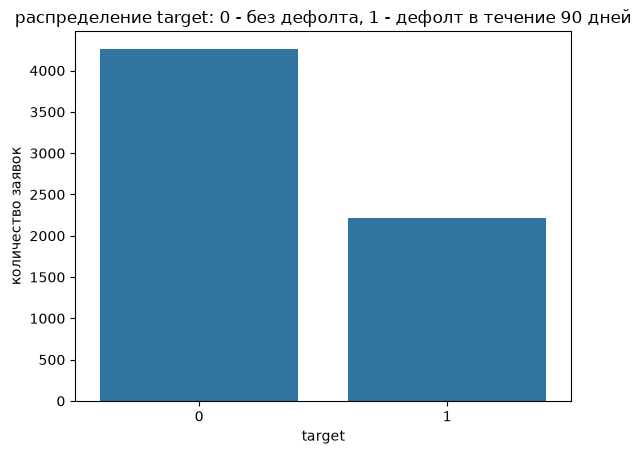

In [118]:
sns.countplot(data=train, x='target')

plt.title("распределение target: 0 - без дефолта, 1 - дефолт в течение 90 дней")
plt.xlabel('target')
plt.ylabel('количество заявок')

plt.show

In [119]:
# распределение классов в train
print(train['target'].value_counts(normalize=True))

target
0    0.657716
1    0.342284
Name: proportion, dtype: float64


Дисбаланс классов. На этапе обучения я буду использовать RepeatedStratifiedKFold для равномерного распределения классов по фолдам

## 4.1 Оценка значимости признаков

Для оценки значимости признаков использую следующий пайплайн. Для каждого признака исследуются статистическая значимость, сила эффекта и информационная ценность (IV).

1. `P-value`. Ориентир: `p < 0.05` - связь с таргетом статистически значима, то есть не объясняется случайностью.

На нашей большой выборке `p-value` может показывать значимость даже при незначительном эффекте, поэтому дополнительно измеряю сила эффекта:

- для категориальных признаков через коэффициент `Крамера` (V)
- для непрерывных признаков — через `n^2` (eta squared)

Пороги по Коэну: 

V < 0.1        — слабая связь
0.1 < V < 0.3  — умеренная
0.3 ≤ V < 0.5  — сильная      
V ≥ 0.5        — очень сильная 

n^2 < 0.01        — слабая связь
0.01 < n^2 < 0.06 — умеренная
0.06 < n^2 < 0.14 — умеренная-сильная 
n^2 > 0.14        — сильная

V/n^2 измеряют связь одним усредненным числом по всей выборке и могут недооценивать признак, если сигнал сосредоточен в отдельных сегментах. IV считается по каждому бину отдельно и суммируется, поэтому решение об исключении признака я принимаю по порогу IV, а p-value/V/n^2 использую как проверку, что этот IV не шум

IV < 0.02        — признак бесполезен
0.02 < IV < 0.1  — слабая связь
0.1 < IV < 0.3   — умеренная связь
0.3 < IV < 0.5   — сильная связь

In [120]:
train.columns

Index(['application_id', 'client_id', 'employment_type', 'region_coefficient_extended', 'age', 'incoming_amount', 'monthly_income',
       'application_date', 'education', 'requested_product', 'channel', 'loan_amount', 'marketing_segment', 'region', 'interest_rate',
       'months_at_job', 'dependents', 'loan_term_months', 'siberia_northern_score', 'target', 'income', 'log_income', 'log_loan_amount',
       'loan_by_income', 'income_per_person', 'transactions_count', 'transactions_amount_sum', 'transactions_amount_mean',
       'transactions_amount_median', 'transactions_amount_std', 'transactions_risk_mean', 'cash_withdrawal', 'entertainment', 'gambling',
       'groceries', 'loan_payment', 'salary', 'transfer', 'utilities', 'days_since_last_transactions', 'cash_flow', 'no_income_transactions',
       'has_bureau', 'bureau_account_id_count', 'credit_limit_sum', 'credit_limit_mean', 'credit_limit_max', 'credit_limit_min', 'credit_limit_std',
       'current_balance_sum', 'current_balan

In [121]:
# вручную задаю список категориальных признаков
categorical_features = [
    'employment_type',
    'region_coefficient_extended',
    'education',
    'requested_product',
    'channel',
    'marketing_segment',
    'region',
    'dependents',                   

    'no_income_transactions',        
    'has_bureau',                   
    'has_previous_loans',          
    'last_loan_was_overdue',   
]

In [122]:
# исключаю из оценки технические признаки
exclude = ['application_id', 'client_id', 'application_date', 'target']

features = [c for c in train.columns if c not in exclude]

# строю таблицу значимости признаков
table = feature_significance_table(features, 'target', train, categorical_features=categorical_features)

In [123]:
# топ 20 самых сильных признаков
table[:20]

,feature,kind,test,p_value,effect,IV
0,max_dpd_last_12m_max,continuous,ttest,0.0,0.1187,0.5756
1,max_dpd_last_12m_sum,continuous,ttest,0.0,0.0996,0.5087
2,max_dpd_last_12m_mean,continuous,ttest,0.0,0.0818,0.4750
3,months_at_job,continuous,ttest,0.0,0.0608,0.3513
4,payment_by_income,continuous,ttest,0.0,0.0961,0.3228
5,loan_by_income,continuous,ttest,0.0,0.0641,0.2550
6,employment_type,categorical,chi2,0.0,0.2296,0.2251
7,loan_to_income,continuous,ttest,0.0,0.0305,0.2017
8,income,continuous,ttest,0.0,0.0276,0.1937
9,log_income,continuous,ttest,0.0,0.0390,0.1937


In [124]:
table[-10:] # топ 10 бесполезных признаков

,feature,kind,test,p_value,effect,IV
70,loan_payment,continuous,ttest,0.3872,0.0001,0.0016
71,siberia_northern_score,continuous,ttest,0.7411,0.0000,0.0013
72,education,categorical,chi2,0.7589,0.0170,0.0011
73,salary,continuous,ttest,0.3568,0.0001,0.0011
74,utilities,continuous,ttest,0.9976,0.0000,0.0007
75,dependents,categorical,chi2,0.6463,0.0255,0.0006
76,days_since_last_transactions,continuous,ttest,0.5543,0.0001,0.0006
77,cash_withdrawal,continuous,ttest,0.8631,0.0000,0.0003
78,no_income_transactions,categorical,chi2,0.7822,0.0034,0.0001
79,was_overdue_sum,continuous,ttest,0.0000,0.0111,0.0000


## 4.2 Выборочный подробный анализ признаков

Вручную разбираю первые признаки по одному. Пайплайн:

1. Гипотеза - что ожидаю увидеть, до просмотра данных
2. Гистограмма распределения — форма, выбросы, доля пропусков
3. WoE-таблица — бины, bad_rate, IV
4. Графики n и bad_rate по бинам — проверка монотонности
5. Вывод

`max_dpd_last_12m_max`

гипотеза: чем больше самая тяжелая просрочка у клиента за последний год, тем выше риск выйти в новую серьезную просрочку

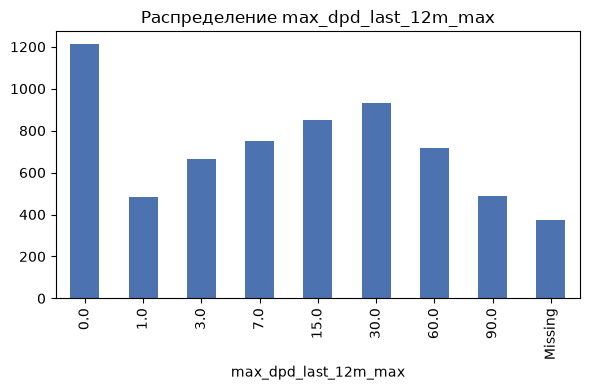

In [125]:
plot_distribution(train, 'max_dpd_last_12m_max')

In [126]:
woe_table, iv = calc_woe_iv(train, 'max_dpd_last_12m_max', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(-0.001, 1.0]",3116,759,0.243582,0.480010,0.101199
"(7.0, 15.0]",853,256,0.300117,0.193607,0.004774
"(15.0, 30.0]",931,354,0.380236,-0.164587,0.003986
"(30.0, 60.0]",717,419,0.584379,-0.993910,0.118264
"(60.0, 90.0]",489,381,0.779141,-1.913801,0.280250
Missing,374,49,0.131016,1.238872,0.067101


In [127]:
print(f"iv: {iv:.4f}")

iv: 0.5756


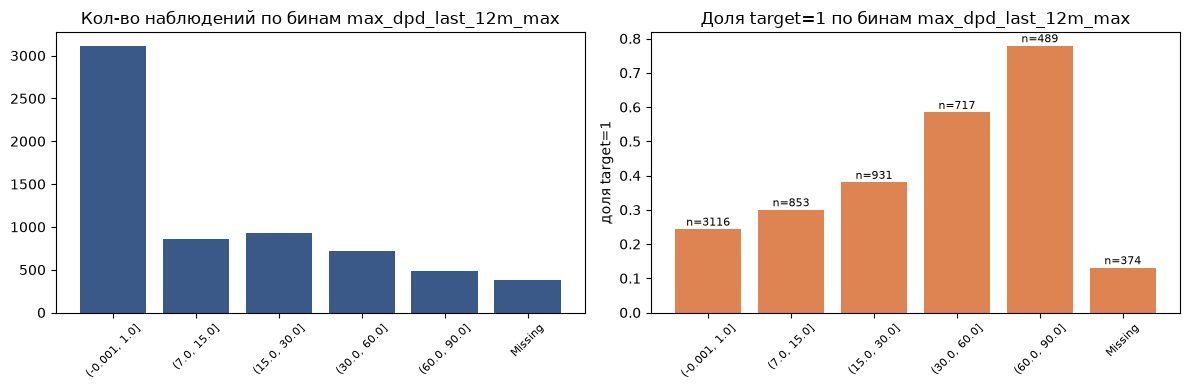

In [128]:
visualization(woe_table, 'max_dpd_last_12m_max', 'target')

Монотонный признак, оценка надежна (все бины > 5% выборки). IV = 0.57, признак сильный, данные не могут быть утечкой, так как информация получена из кредитной истории клиента. Бин пропущенных значений дает самый низкий bad_rate (13%). Можно сделать вывод, что отсутствие кредитной истории уменьшает риск выйти в серьезную просрочку. Признак оставляю как один из ключевых

`max_dpd_last_12m_sum` и `max_dpd_last_12m_mean`

гипотеза: чем больше суммарная или средняя просрочка у клиента за последний год, тем выше риск выйти в новую серьезную просрочку

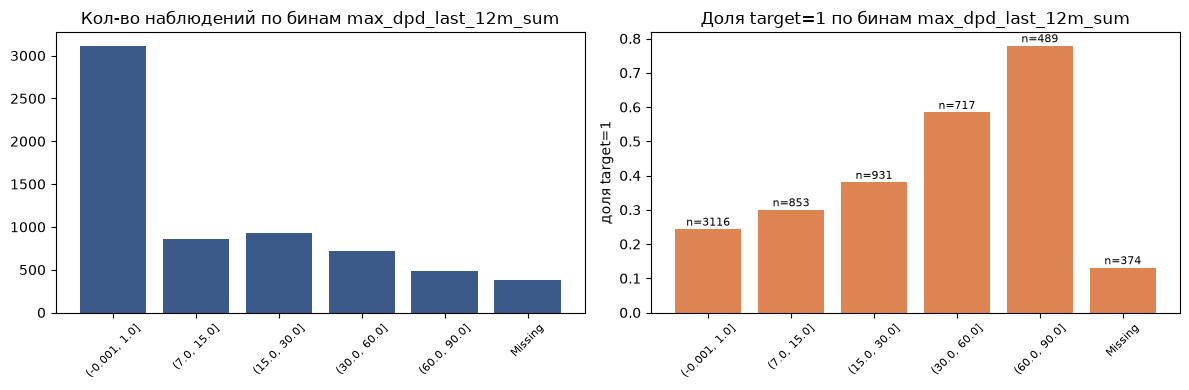

In [129]:
visualization(woe_table, 'max_dpd_last_12m_sum', 'target')

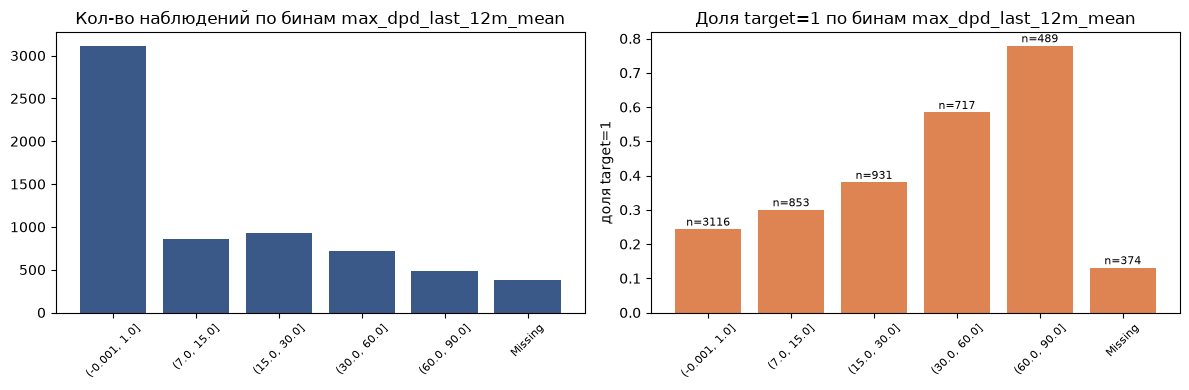

In [130]:
visualization(woe_table, 'max_dpd_last_12m_mean', 'target')

Графики среднего и суммы просрочек по аналогии монотонны

`months_at_job`

гипотеза: меньше рабочий стаж -> меньше карьерный рост -> меньше заработная плата -> выше риск просрочки

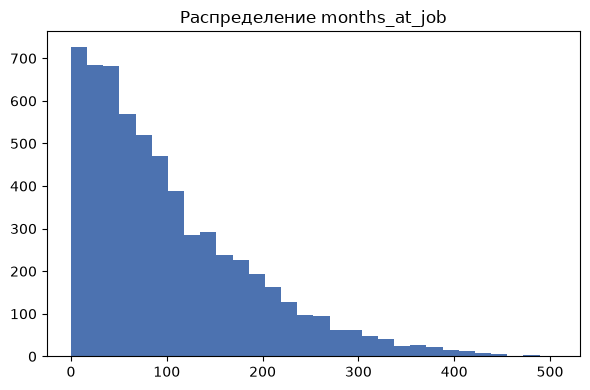

In [131]:
plot_distribution(train, 'months_at_job')

In [132]:
woe_table, iv = calc_woe_iv(train, 'months_at_job', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(-0.001, 13.0]",1249,662,0.530024,-0.773373,0.124311
"(29.0, 43.0]",1219,550,0.451189,-0.457267,0.041612
"(61.0, 79.5]",1211,391,0.322874,0.087464,0.001409
"(102.0, 131.0]",1196,267,0.223244,0.593727,0.057944
"(170.4, 225.7]",1219,213,0.174733,0.899313,0.125910
Missing,386,135,0.349741,-0.032954,0.000065


In [133]:
print(f"IV = {iv:.4f}")

IV = 0.3513


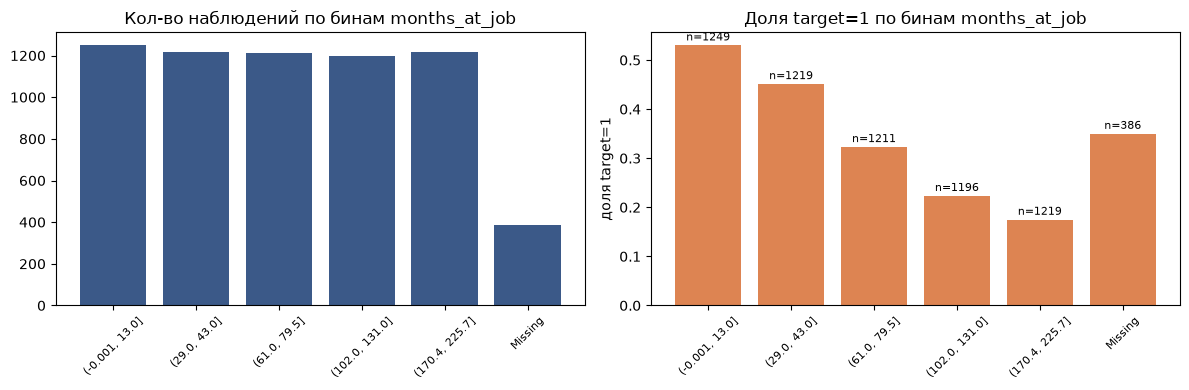

In [134]:
visualization(woe_table, 'months_at_job', 'target')

Признак монотонный, шанс просрочки уменьшается с ~ 53% в первом бине до ~ 17% в последнем числовом. Все бины > 5% выборки, оценка надежна. Бин с пропущенными значениями не несет сигнала, люди без стажа ведут себя в среднем одинаково. Оставляю признак как один из ключевых

`payment_by_income`

гипотеза: чем выше доля ежемесечной выплаты по кредиту к ежемесечному доходу тем больше шансов выйти в серьезную просрочку

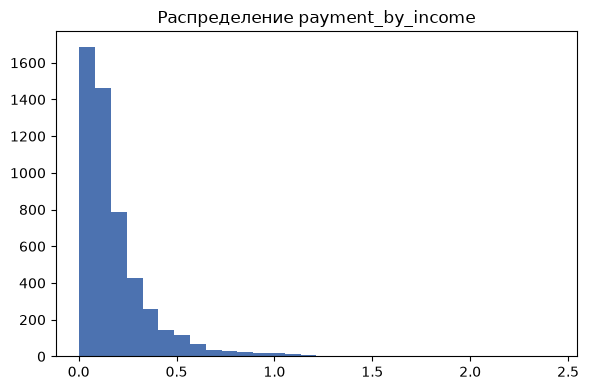

In [135]:
plot_distribution(train, 'payment_by_income')

In [136]:
woe_table, iv = calc_woe_iv(train, 'payment_by_income', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(0.0029, 0.0412]",1535,346,0.225407,0.581296,0.071488
"(0.0781, 0.1]",1024,267,0.260742,0.388982,0.022264
"(0.127, 0.159]",1023,318,0.310850,0.143014,0.003152
"(0.202, 0.27]",1023,448,0.437928,-0.403556,0.027067
"(0.4, 2.425]",512,363,0.708984,-1.543589,0.198661
Missing,1363,476,0.349230,-0.030706,0.000199


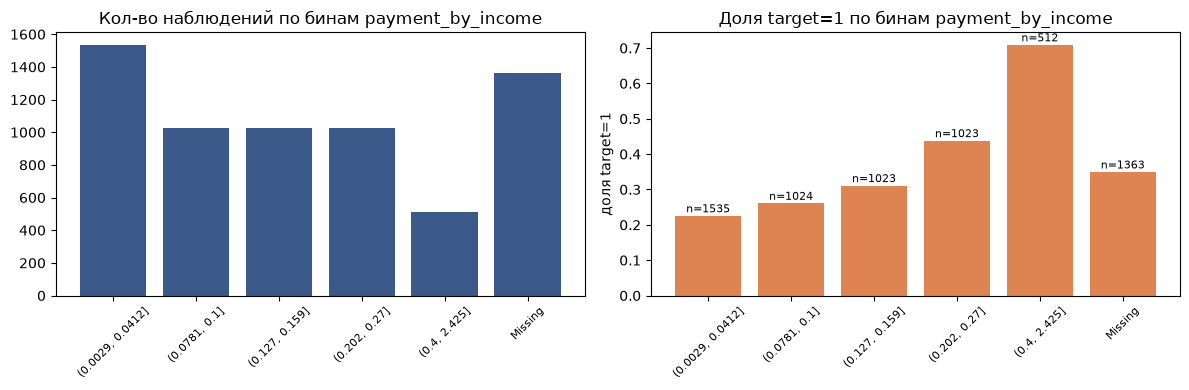

In [137]:
visualization(woe_table, 'payment_by_income', 'target')

Монотонный признак, доля просрочек растет равномерно с 1 по 4 сегмент (22% - 43%), в последнем числовом сегменте выброс - просрочки составляет 70%. Оценка надежна, все бины > 5% от выборки. Гипотеза подтверждена. Оставляю как один из ключевых признаков.

`loan_by_income`

гипотеза - чем больше отношение долга к доходу (долг превышает доход), тем выше риск выйти в серьезную просрочку

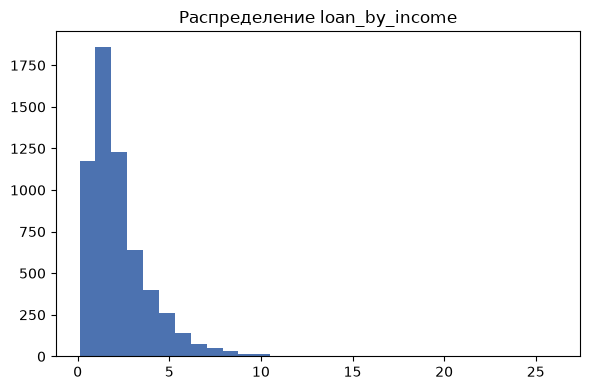

In [138]:
plot_distribution(train, 'loan_by_income')

In [139]:
woe_table, iv = calc_woe_iv(train, 'loan_by_income', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(0.10099999999999999, 0.707]",1770,402,0.227119,0.571520,0.079860
"(1.226, 1.491]",1769,520,0.293951,0.223137,0.013078
"(2.14, 2.585]",1180,428,0.362712,-0.089520,0.001479
"(3.254, 4.463]",590,289,0.489831,-0.612449,0.036547
"(4.463, 26.115]",590,362,0.613559,-1.115431,0.122379
Missing,581,217,0.373494,-0.135876,0.001689


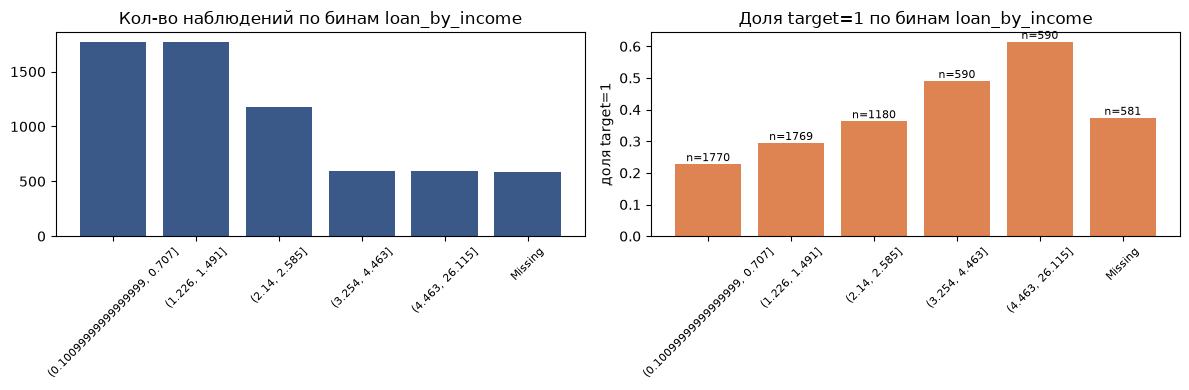

In [140]:
visualization(woe_table, 'loan_by_income', 'target')

Признак монотонный, от ~22 % до 61 % просрочки в последнем числовом бине. Бин с пропущенными значениями не несет сигнала. Оценка надежна, все бины больше 5 % выборки. Оставляю признак. Гипотеза подтверждена

`employment_type`

гипотеза: безработный клиент -> меньше финансовой стабильности -> больше риск выйти в просрочку

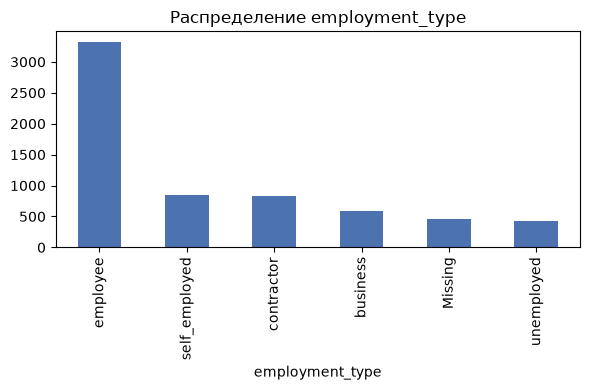

In [141]:
plot_distribution(train, 'employment_type')

In [142]:
woe_table, iv = calc_woe_iv(train, 'employment_type', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
employee,3327,981,0.294860,0.218762,0.023660
contractor,823,362,0.439854,-0.411379,0.022644
Missing + self_employed,1311,418,0.318841,0.105973,0.002233
unemployed,429,303,0.706294,-1.530584,0.163843
business,590,154,0.261017,0.387557,0.012738


In [143]:
print(f"IV = {iv:.4f}")

IV = 0.2251


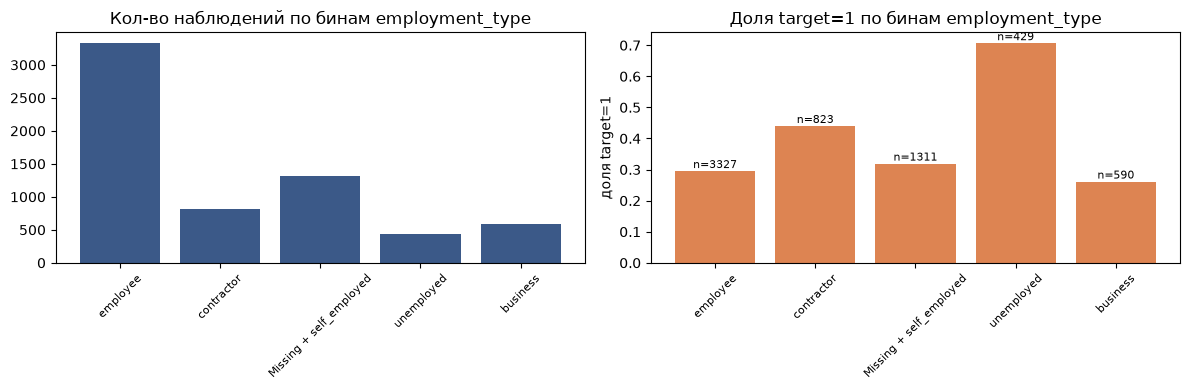

In [144]:
visualization(woe_table, 'employment_type', 'target')

Значительный выброс в unemployed - 70 % просрочки против 26-43 % в других категориях. Вклад категории в общую IV 0.164 из 0.225, то есть около 73% предсказательной силы. Оценка надежна, минимальное кол-во наблюдений в unemployed = 429, выше 5%. Самый низкий риск просрочки ожидаемо у employee/buisness. 

Функция смержила категорию с пропущенными значениями с self_employed, потому что их bad_rate статистически неразличим. Гипотеза: люди, которые не указали тип занятости чаще всего являются самозанятыми

`log_income`, `income` (`monthly_income` | `incoming_amount`) - имеют одинаковую `IV`

гипотеза: выше доход -> ниже риск просрочки

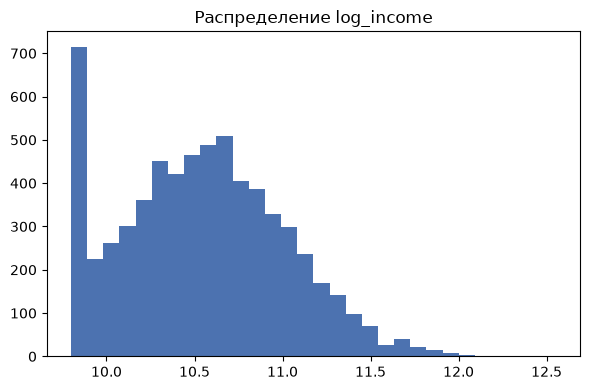

In [145]:
plot_distribution(train, 'log_income')

In [146]:
woe_table, iv = calc_woe_iv(train, 'log_income', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(9.797, 9.859]",646,367,0.568111,-0.927283,0.092730
"(9.859, 10.102]",645,299,0.463566,-0.507137,0.027195
"(10.102, 10.272]",645,255,0.395349,-0.228249,0.005355
"(10.272, 10.407]",2580,818,0.317054,0.114210,0.005096
"(10.789, 10.944]",1964,479,0.243890,0.478337,0.063364


In [147]:
print(f"IV = {iv:.4f}")

IV = 0.1937


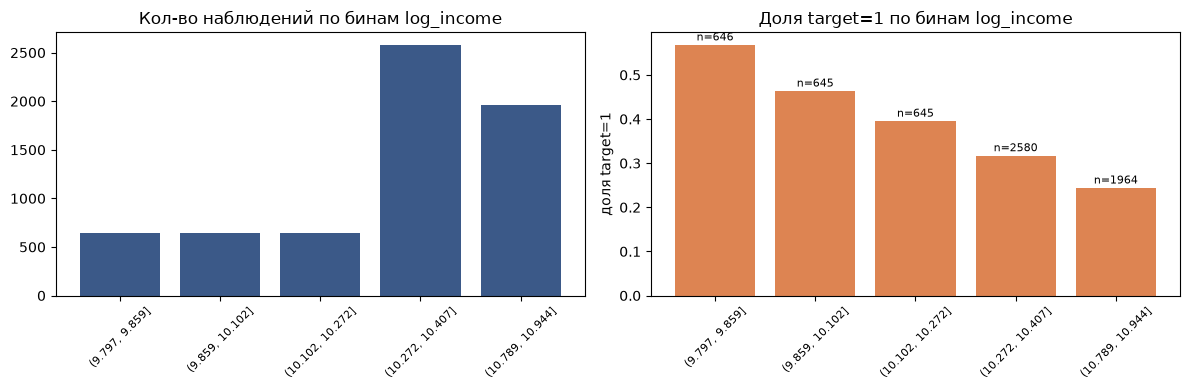

In [148]:
visualization(woe_table, 'log_income', 'target')

Монотонный признак, от ~ 56% просрочки у людей с самым низким доходом до ~ 24% у людей с высоким доходом. Признак надежный, количества наблюдений достаточно (выше 5% выборки в каждом бине). Гипотеза подтверждена

`transactions_amount_median`

типичный размер разового расхода/дохода клиента

крупная отрицательная медианная транзакция может означать либо более состоятельного клиента (риск просрочки ниже), либо отсутствие финансовой дисциплины (риск просрочки выше) 

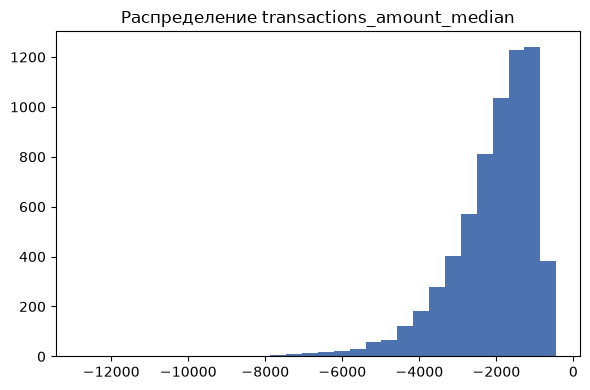

In [149]:
plot_distribution(train, 'transactions_amount_median')

In [150]:
woe_table, iv = calc_woe_iv(train, 'transactions_amount_median', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(-12821.491, -3561.715]",1296,306,0.236111,0.520987,0.049141
"(-2849.834, -2415.742]",2592,784,0.302469,0.182435,0.012906
"(-1597.678, -1380.129]",648,229,0.353395,-0.048984,0.000242
"(-1380.129, -1156.88]",1296,545,0.420525,-0.332513,0.023112
"(-953.753, -445.84]",648,354,0.546296,-0.838850,0.076018


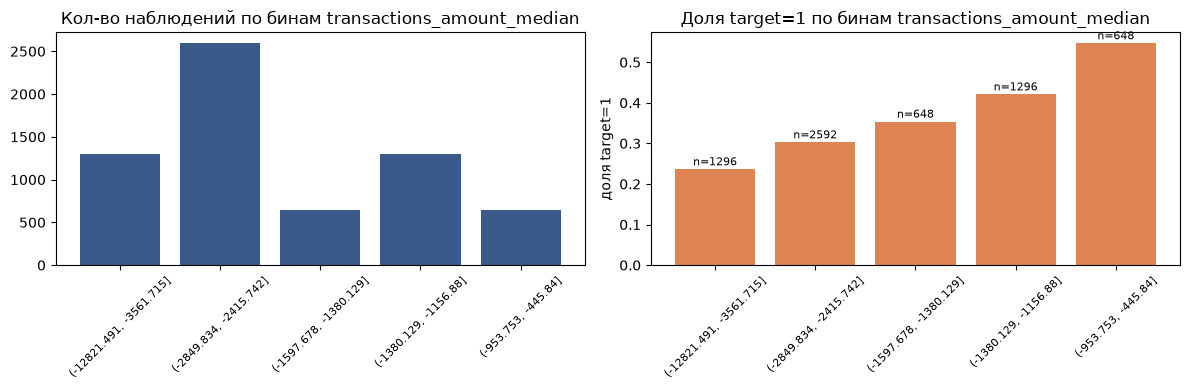

In [151]:
visualization(woe_table, 'transactions_amount_median', 'target')

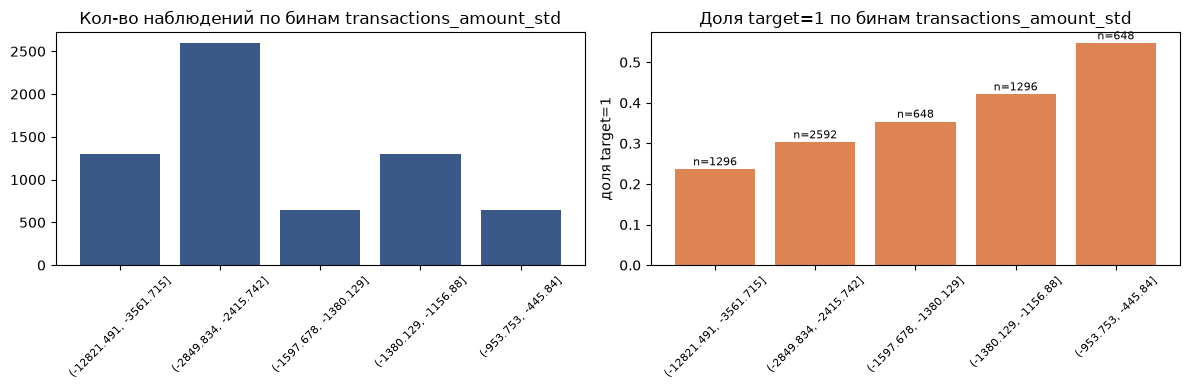

In [152]:
visualization(woe_table, 'transactions_amount_std', 'target')

Признак монотонный: чем мельче типичная разовая трата клиента, тем выше bad_rate (23.6% -> 54.4%). Подтверждает гипотезу, что крупные
типичные расходы ассоциируются с финансовой стабильностью, а не с жизнью не по средствам. Пропусков нет. Признак оставляю

`age` 

молодые клиенты, вероятно, имеют меньше опыта работы, находятся на более низких должностях чем старшие коллеги, следовательно, имеют в среднем меньше финансовой стабильности и выше риск выйти в серьезную просрочку

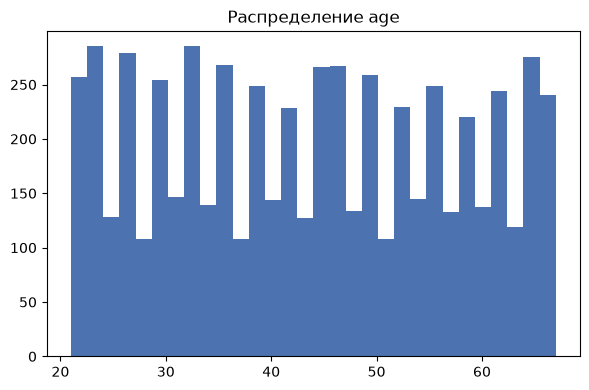

In [153]:
plot_distribution(train, 'age')

In [154]:
woe_table, iv = calc_woe_iv(train, 'age', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(20.999, 25.0]",670,336,0.501493,-0.659103,0.048194
"(25.0, 30.0]",1212,517,0.426568,-0.357264,0.025017
"(34.0, 39.0]",1263,439,0.347585,-0.023462,0.000108
"(44.0, 48.0]",2371,668,0.281738,0.282726,0.027822
"(63.0, 67.0]",515,102,0.198058,0.745342,0.037949
Missing,449,156,0.347439,-0.022816,0.000036


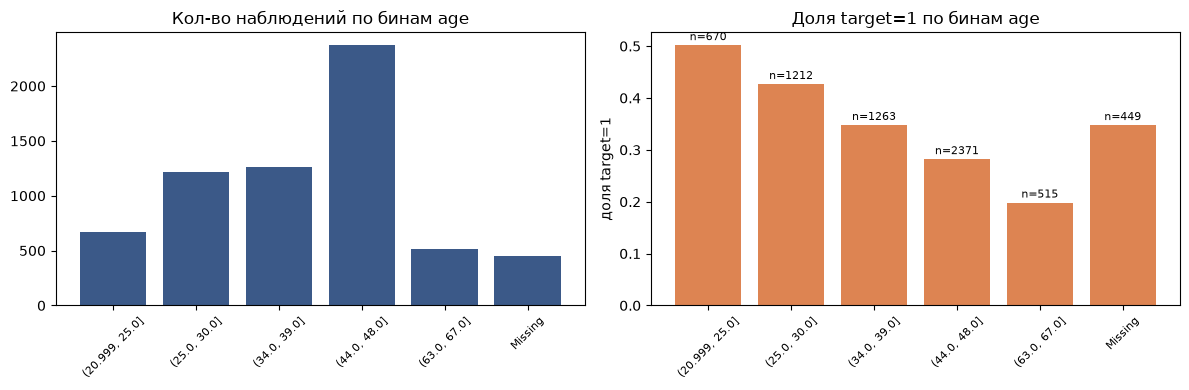

In [155]:
visualization(woe_table, 'age', 'target')

Монотонный признак, чем меньше возраст, тем выше риск просрочки (20-25 лет - 50 % просрочки). Бин с пропусками не несет интересного сигнала. Количество наблюдений достаточно, чтобы считать оценку надежной (каждый бин > 5% от выборки)

`bureau_account_id_count` 

чем больше у клиента открыто кредитных счетов, тем больше на нем кредитная нагрузка, тем больше шанс выйти в серьезную просрочку при взятии нового кредита

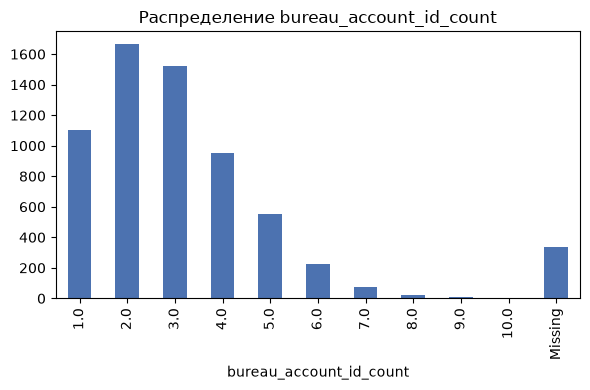

In [156]:
plot_distribution(train, 'bureau_account_id_count')

In [157]:
woe_table, iv = calc_woe_iv(train, 'bureau_account_id_count', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(0.999, 2.0]",2771,851,0.307109,0.160536,0.010726
"(2.0, 3.0]",2479,921,0.371521,-0.127434,0.006331
"(4.0, 5.0]",893,404,0.452408,-0.462185,0.031156
Missing,337,42,0.124629,1.296173,0.065172


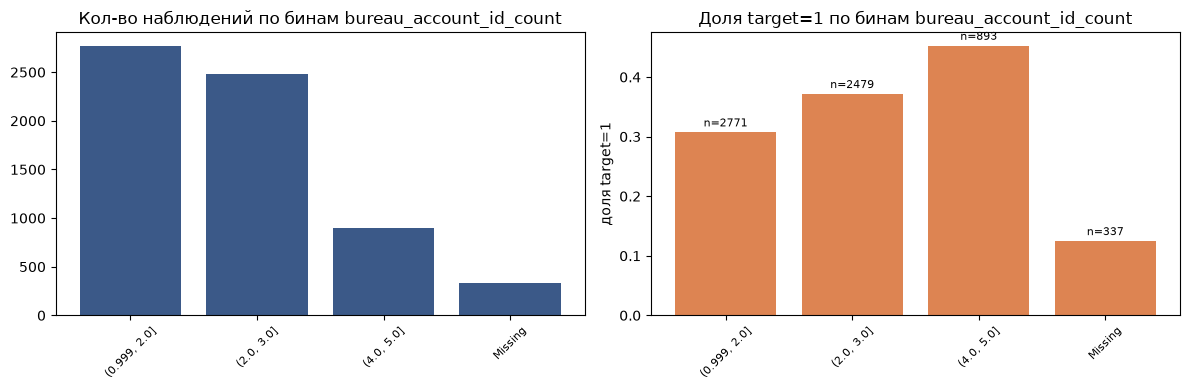

In [158]:
visualization(woe_table, 'bureau_account_id_count', 'target')

Монотонный признак, наибольший риск просрочки в последнем бине у людей с 4-5 кредитными счетами (~45% просрочки). Пропуски не несут дополнительного сигнала. Оценка надежна, каждый бин больше 5 % от выборки

`interest_rate` 

гипотеза: чем выше процентная ставка по кредиту, тем выше кредитная нагрузка -> выше шанс выйти в просрочку 

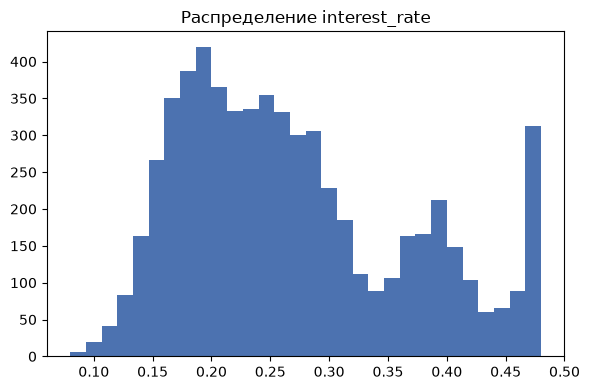

In [159]:
plot_distribution(train, 'interest_rate')

In [160]:
woe_table, iv = calc_woe_iv(train, 'interest_rate', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(0.079, 0.161]",612,278,0.454248,-0.469613,0.022058
"(0.161, 0.184]",2445,895,0.366053,-0.103946,0.004141
"(0.251, 0.276]",1827,568,0.310892,0.142819,0.005615
"(0.369, 0.415]",610,162,0.265574,0.364064,0.011678
"(0.415, 0.48]",986,315,0.319473,0.103064,0.001589


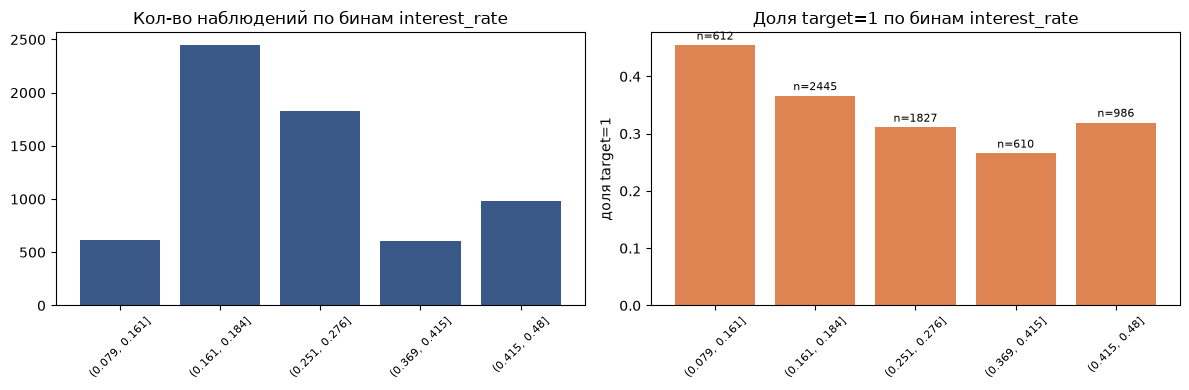

In [161]:
visualization(woe_table, 'interest_rate', 'target')

Контринтуитивная связь признака с целевой переменной: 4 бина наблюдается снижение риска со снижением процентной ставки (45 % против 26%), потом плато в районе 31% просрочки. Гипотеза не подтверждена

`utilization_max` 

гипотеза: чем выше доля использованного лимита по счетам, тем меньше финансовая стабильность клиента -> выше риск выйти в просрочку

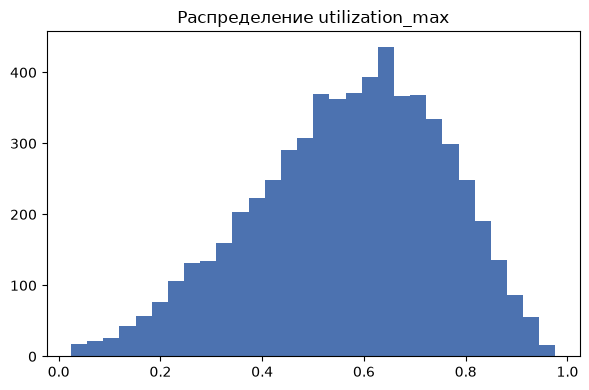

In [162]:
plot_distribution(train, 'utilization_max')

In [163]:
woe_table, iv = calc_woe_iv(train, 'utilization_max', 'target')
woe_table

,n,bad,bad_rate,woe,iv_bin
bin,,,,,
"(0.0231, 0.309]",608,133,0.218750,0.619833,0.031913
"(0.309, 0.407]",608,179,0.294408,0.220938,0.004409
"(0.407, 0.478]",1216,417,0.342928,-0.002858,0.000002
"(0.534, 0.587]",3648,1427,0.391173,-0.210749,0.025765
Missing,400,62,0.155000,1.042779,0.053549


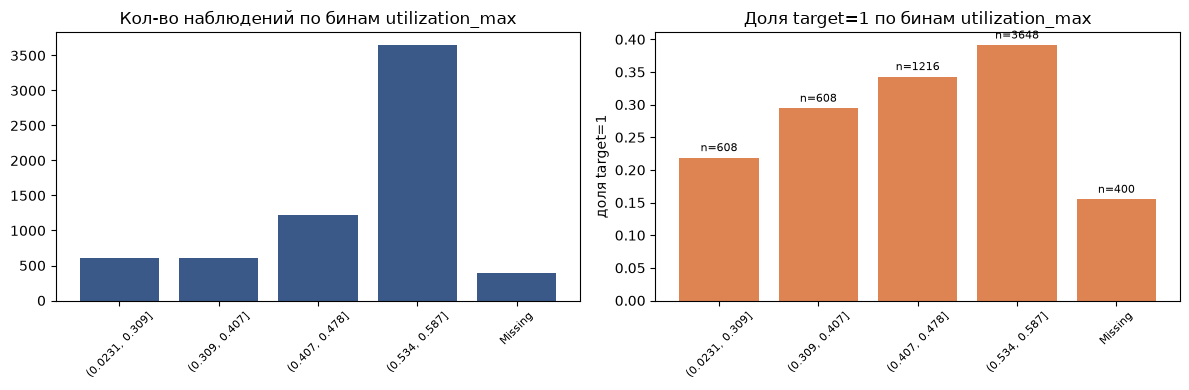

In [164]:
visualization(woe_table, 'utilization_max', 'target')

Монотонный признак, риск равномерно растет с 21% до 39 % в последнем сегменте

**Выводы по EDA**

Все признаки прошли проверку через `p-value` + `V`/`n^2` + `IV`, финальное
решение об исключении будет приниматься по порогу IV, так как он менее чувствителен к сегментированным
эффектам, чем усредненные `V` и `n^2` по всей выборке

По итогам удаляю все признаки с `IV` < 0.02, кроме `gambling`. Отдельная проверка SHAP
(на полном наборе признаков без фильтрации) показала, что он входит в топ-20 по важности
для `lgmm`, несмотря на низкий `IV`. Вероятно, `IV` не улавливает вклад признака в комбинации
с другими признаками

Все монотонные признаки сначала собрал в monotone_features, чтобы на обучении передать их явно lgbm и catboost через параметр **monotone_constraints**. Однако на этапе обучения эта стратегия оказалась неэффективной, поэтому отказался от нее. 

In [165]:
# удаляю все признаки с IV < 0.02, кроме gambling
features_to_drop = set([feature for feature in table[table['IV'] < 0.02]['feature'].tolist()]) - {'gambling'}

features_to_drop.update([
    # признаки объединенные в income
    'incoming_amount', 'monthly_income', 
    # бесполезный признак для модели
    'application_date',
    # логарифмированные признаки
    'income', 'loan_amount'
])

In [166]:
train = train.drop(columns=features_to_drop, errors='ignore')
test = test.drop(columns=features_to_drop, errors='ignore')

# 5. Обучение и валидация

Пайплайн:

1. Для логистической регрессии делаю отдельный набор признаков через WoE-трансформацию — числовые признаки бью на бины по квантилям, категориальные кодирую по самим категориям, пропуски идут отдельным бином. WoE считаю только на train-части фолда, чтобы не было утечки таргета в валидацию

2. Для бустинга кодирую категориальные переменные с помощью OrdinalEncoder

3. Отбираю признаки по важности catboost. Фильтр по `IV` не видит избыточности, поэтому после него остаются дублирующие друг друга агрегаты. Отбор, как и woe, пересчитывается на train-части каждого фолда

4. В валидации использую StratifiedKFold, 5 фолдов, чтобы доля дефолтов была одинаковой в каждом сплите

5. Гиперпараметры каждой модели подбираю отдельно перебором через GridSearch.

Комментарий: изначально я протестировал блендинг трех моделей (`logreg`, `lgmc`, `random forest`), но оказалось, что `random forest` уступал по `roc-auc` всем моделям и немного тянул бленд вниз, поэтому я удалил `RandomForestClassifier` из финального ноутбука

In [167]:
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    ParameterSampler,
    cross_val_score,
)

import lightgbm as lgb
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

import itertools

# StratifiedKFold для сохранения баланса классов
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
# повторное разбиение для более устойчивой оценки метрик
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2)

## 5.1 Подготовка признаков

In [168]:
# все признаки для моделей, кроме технических и target
features_raw = [c for c in train.columns if c not in ['target', 'application_id', 'client_id']]

# обновляю признаки после удаления бесполезных
categorical_features = [c for c in categorical_features if c in features_raw]
numeric_features = [c for c in features_raw if c not in categorical_features]

print(f"всего признаков: {len(features_raw)}, категориальных: {len(categorical_features)}, числовых: {len(numeric_features)}")

всего признаков: 47, категориальных: 4, числовых: 43


In [169]:
# кодирование категориальных переменных для корректной работы lgmc

cat_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1,
    encoded_missing_value=-2,
).fit(train[categorical_features])

X_train_raw = train[features_raw].copy()
X_test_raw = test[features_raw].copy()

X_train_raw[categorical_features] = cat_encoder.transform(train[categorical_features]) + 2
X_test_raw[categorical_features] = cat_encoder.transform(test[categorical_features]) + 2

In [170]:
# кодираю признаки для CatBoost отдельно
X_train_cb = train[features_raw].copy()
X_train_cb[categorical_features] = X_train_cb[categorical_features].astype('object').fillna('Missing').astype(str)

X_test_cb = test[features_raw].copy()
X_test_cb[categorical_features] = X_test_cb[categorical_features].astype('object').fillna('Missing').astype(str)


In [171]:
# woe-трансформация признаков для корректной работы logreg

X_train_woe = pd.DataFrame(index=train.index)
for feature in features_raw:
    is_cat = feature in categorical_features
    fitted = fit_woe(train, feature, 'target', is_categorical=is_cat)
    X_train_woe[feature] = transform_woe(train, feature, fitted)

## 5.2 Поиск оптимальных гиперпараметров моделей

In [ ]:
# поиск оптимальных параметров для логистической регресси через grid search
param_grid_logreg = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
}

search_logreg = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=1),
    param_grid=param_grid_logreg,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
)

search_logreg.fit(X_train_woe, train['target'])

print('Лучшие параметры log_reg:', search_logreg.best_params_)
print('Лучший CV roc_auc:', search_logreg.best_score_)

/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. 

Лучшие параметры log_reg: {'C': 0.1, 'penalty': 'l2'}
Лучший CV roc_auc: 0.8387948646419338


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
# Поиск оптимальных гиперпараметров lgbmc через RandomizedSearch:
param_dist = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 3, 5, 7, 10],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'min_child_samples': [10, 20, 50, 100],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [0, 0.1, 1, 5],
    'subsample': [0.6, 0.8, 1.0],        
    'colsample_bytree': [0.6, 0.8, 1.0],  
}

# случайно сэмплирую n_iter=100 комбинаций
n_iter = 100
sampled_params = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=1))

# для каждой комбинации считаю средний ROC-AUC и число итераций по фолдам skf
# с ранней остановкой (early_stopping=50), результаты сортируются по mean_auc
results = []
for params in sampled_params:
    fold_aucs, fold_best_iters = [], []
    for train_idx, val_idx in skf.split(X_train_raw, train['target']):
        X_tr, X_val = X_train_raw.iloc[train_idx], X_train_raw.iloc[val_idx]
        y_tr, y_val = train['target'].iloc[train_idx], train['target'].iloc[val_idx]

        model = lgb.LGBMClassifier(
            n_estimators=2000,   # верхняя граница
            subsample_freq=1,    
            random_state=1,
            verbose=-1,
            **params,
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        fold_aucs.append(model.best_score_['valid_0']['auc'])
        fold_best_iters.append(model.best_iteration_)

    results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs),
                     'mean_best_iter': int(np.mean(fold_best_iters))})

results_df = pd.DataFrame(results).sort_values('mean_auc', ascending=False)
results_df.head(10)


/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_

,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_depth,learning_rate,colsample_bytree,mean_auc,std_auc,mean_best_iter
75,0.8,1.0,0.0,127,100,5,0.05,0.6,0.833241,0.009309,124
30,0.8,1.0,0.0,127,100,3,0.01,0.8,0.833222,0.009060,863
70,0.8,0.1,0.1,31,10,3,0.03,0.8,0.833149,0.008520,324
65,0.8,0.0,0.1,63,10,3,0.10,0.8,0.833142,0.009422,103
68,0.8,5.0,1.0,31,50,3,0.03,0.8,0.833122,0.008145,321
99,0.6,5.0,0.0,127,50,3,0.01,0.8,0.832782,0.008637,821
80,0.6,5.0,0.0,15,10,3,0.03,1.0,0.832727,0.008512,330
78,0.8,0.1,5.0,15,100,5,0.03,0.6,0.832646,0.009084,257
90,0.8,5.0,0.1,127,10,3,0.03,0.8,0.832633,0.008191,294
50,0.8,0.1,5.0,63,100,3,0.03,1.0,0.832615,0.008869,332


In [106]:
# переоцениваю топ-10 комбинаций из RandomizedSearch на RepeatedStratifiedKFold 
# для более устойчивой оценки ROC-AUC

param_cols = ['num_leaves', 'max_depth', 'learning_rate', 'min_child_samples',
              'reg_alpha', 'reg_lambda', 'subsample', 'colsample_bytree']

shortlist = results_df.head(10)[param_cols].to_dict('records')

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)

final_results = []
for params in shortlist:
    fold_aucs, fold_best_iters = [], []
    for train_idx, val_idx in rskf.split(X_train_raw, train['target']):
        X_tr, X_val = X_train_raw.iloc[train_idx], X_train_raw.iloc[val_idx]
        y_tr, y_val = train['target'].iloc[train_idx], train['target'].iloc[val_idx]

        model = lgb.LGBMClassifier(
            n_estimators=2000,
            subsample_freq=1,
            random_state=1,
            verbose=-1,
            **params,
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        fold_aucs.append(model.best_score_['valid_0']['auc'])
        fold_best_iters.append(model.best_iteration_)

    final_results.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs),
                           'mean_best_iter': int(np.mean(fold_best_iters))})

final_results_df = pd.DataFrame(final_results).sort_values('mean_auc', ascending=False)
final_results_df

/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/anaconda3/envs/study/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_

,num_leaves,max_depth,learning_rate,min_child_samples,reg_alpha,reg_lambda,subsample,colsample_bytree,mean_auc,std_auc,mean_best_iter
1,127,3,0.01,100,0.0,1.0,0.8,0.8,0.833958,0.007292,814
6,15,3,0.03,10,0.0,5.0,0.6,1.0,0.833920,0.007217,274
0,127,5,0.05,100,0.0,1.0,0.8,0.6,0.833863,0.008138,122
5,127,3,0.01,50,0.0,5.0,0.6,0.8,0.833844,0.007461,845
9,63,3,0.03,100,5.0,0.1,0.8,1.0,0.833833,0.007180,355
4,31,3,0.03,50,1.0,5.0,0.8,0.8,0.833812,0.007015,342
2,31,3,0.03,10,0.1,0.1,0.8,0.8,0.833775,0.006678,273
8,127,3,0.03,10,0.1,5.0,0.8,0.8,0.833663,0.006890,308
7,15,5,0.03,100,5.0,0.1,0.8,0.6,0.833182,0.007653,248
3,63,3,0.10,10,0.1,0.0,0.8,0.8,0.832038,0.007519,87


In [ ]:
# Grid search по гиперпараметрам catboost
# оценка каждой по CV (skf) с early stopping, сортировка по среднему roc_auc.

param_grid_catboost = {
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 10],
    'learning_rate': [0.01, 0.03, 0.1],
    'bagging_temperature': [0, 1, 5],
}

keys = list(param_grid_catboost.keys())
combinations = list(itertools.product(*param_grid_catboost.values()))

results_cb = []
for combo in tqdm(combinations):
    params = dict(zip(keys, combo))
    fold_aucs, fold_best_iters = [], []
    for train_idx, val_idx in skf.split(X_train_cb, train['target']):
        X_tr, X_val = X_train_cb.iloc[train_idx], X_train_cb.iloc[val_idx]
        y_tr, y_val = train['target'].iloc[train_idx], train['target'].iloc[val_idx]

        model = CatBoostClassifier(
            iterations=2000,
            cat_features=categorical_features,
            eval_metric='AUC',
            random_state=1,
            verbose=False,
            **params,
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50)

        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        fold_best_iters.append(model.get_best_iteration())

    results_cb.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs),
                        'mean_best_iter': int(np.mean(fold_best_iters))})

results_cb_df = pd.DataFrame(results_cb).sort_values('mean_auc', ascending=False)
results_cb_df.head(10)


100%|██████████| 108/108 [29:39<00:00, 16.48s/it]


,depth,l2_leaf_reg,learning_rate,bagging_temperature,mean_auc,std_auc,mean_best_iter
3,4,1,0.03,0,0.836362,0.008687,333
4,4,1,0.03,1,0.836362,0.008687,333
5,4,1,0.03,5,0.836362,0.008687,333
23,4,5,0.03,5,0.836130,0.008464,371
22,4,5,0.03,1,0.836130,0.008464,371
21,4,5,0.03,0,0.836130,0.008464,371
13,4,3,0.03,1,0.836029,0.009383,410
14,4,3,0.03,5,0.836029,0.009383,410
12,4,3,0.03,0,0.836029,0.009383,410
32,4,10,0.03,5,0.835943,0.009342,364


In [111]:
# этап 2: переоцениваю топ-10 комбинаций catboost на rskf 
# для более устойчивой оценки roc_auc

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
shortlist = results_cb_df.head(10)[keys].to_dict('records')

final_results_cb = []
for params in tqdm(shortlist):
    fold_aucs, fold_best_iters = [], []
    for train_idx, val_idx in rskf.split(X_train_cb, train['target']):
        X_tr, X_val = X_train_cb.iloc[train_idx], X_train_cb.iloc[val_idx]
        y_tr, y_val = train['target'].iloc[train_idx], train['target'].iloc[val_idx]

        model = CatBoostClassifier(
            iterations=2000,
            cat_features=categorical_features,
            eval_metric='AUC',
            random_state=1,
            verbose=False,
            **params,
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50)

        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        fold_best_iters.append(model.get_best_iteration())

    final_results_cb.append({**params, 'mean_auc': np.mean(fold_aucs), 'std_auc': np.std(fold_aucs),
                              'mean_best_iter': int(np.mean(fold_best_iters))})

final_results_cb_df = pd.DataFrame(final_results_cb).sort_values('mean_auc', ascending=False)
final_results_cb_df



100%|██████████| 10/10 [05:16<00:00, 31.67s/it]


,depth,l2_leaf_reg,learning_rate,bagging_temperature,mean_auc,std_auc,mean_best_iter
0,4,1,0.03,0,0.837071,0.007558,339
1,4,1,0.03,1,0.837071,0.007558,339
2,4,1,0.03,5,0.837071,0.007558,339
3,4,5,0.03,5,0.836910,0.007309,341
4,4,5,0.03,1,0.836910,0.007309,341
5,4,5,0.03,0,0.836910,0.007309,341
6,4,3,0.03,1,0.836820,0.007995,369
7,4,3,0.03,5,0.836820,0.007995,369
8,4,3,0.03,0,0.836820,0.007995,369
9,4,10,0.03,5,0.836252,0.007732,324


## 5.3 Валидация

In [172]:
# подобранные гиперпараметры

params_log_reg = dict(class_weight='balanced', max_iter=5000, penalty='l2', C=0.1, random_state=1)

params_lgmm = dict(num_leaves=127, max_depth=3, n_estimators=900, min_child_samples=100,
                   learning_rate=0.01, reg_alpha=0.0, reg_lambda=1.0, subsample=0.8,
                   colsample_bytree=0.8, random_state=1, verbose=-1)

params_catboost = dict(n_estimators=400, depth=4, l2_leaf_reg=1, learning_rate=0.03,
                       bagging_temperature=0, verbose=False, random_state=1)


def make_models(cat_features):
    """
    Создает три модели logreg, lgmc и catboost
    """
    return (
        LogisticRegression(**params_log_reg),
        LGBMClassifier(**params_lgmm),
        CatBoostClassifier(cat_features=cat_features, **params_catboost),
    )

In [173]:
features_raw

['employment_type',
 'age',
 'requested_product',
 'interest_rate',
 'months_at_job',
 'loan_term_months',
 'log_income',
 'log_loan_amount',
 'loan_by_income',
 'income_per_person',
 'transactions_amount_sum',
 'transactions_amount_mean',
 'transactions_amount_median',
 'transactions_amount_std',
 'gambling',
 'has_bureau',
 'bureau_account_id_count',
 'credit_limit_sum',
 'credit_limit_mean',
 'credit_limit_max',
 'credit_limit_min',
 'credit_limit_std',
 'current_balance_sum',
 'current_balance_mean',
 'current_balance_max',
 'current_balance_min',
 'max_dpd_last_12m_max',
 'max_dpd_last_12m_min',
 'max_dpd_last_12m_mean',
 'max_dpd_last_12m_sum',
 'utilization_gen',
 'bureau_active_status',
 'auto',
 'consumer',
 'credit_card',
 'microloan',
 'mortgage',
 'utilization_max',
 'utilization_mean',
 'was_overdue_mean',
 'max_overdue_days_max',
 'max_overdue_days_sum',
 'last_loan_was_overdue',
 'last_loan_max_overdue_days',
 'loan_to_income',
 'monthly_loan_payment',
 'payment_by_incom

**Дополнительный отбор признаков**

`IV` оценивает каждый признак изолированно и не видит,
что несколько признаков могут дублировать друг друга. Среди них
8 признаков — это агрегаты (`sum`/`mean`/`max`/`min`/`std`) двух одних и тех же колонок `bureau`
(`credit_limit` и `current_balance`). Поэтому добавляю второй отбор: ранжирую признаки по важности `catboost` и оставляю top-20

In [174]:
N_TOP_FEATURES = 20


def select_top_features(df, features, n_top=N_TOP_FEATURES, n_splits=10, random_state=5):
    """
    Дополнительный отбор признаков по важности catboost.
    Возвращает список из n_top признаков и полную таблицу средних рангов
    """
    cat_features = [c for c in categorical_features if c in features]

    X = df[features].copy()
    X[cat_features] = X[cat_features].astype('object').fillna('Missing').astype(str)
    y = df['target']

    ranks = []
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for train_idx, _ in splitter.split(X, y):
        model = CatBoostClassifier(cat_features=cat_features, **params_catboost)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        ranks.append(pd.Series(model.get_feature_importance(), index=features).rank(ascending=False))

    mean_rank = pd.concat(ranks, axis=1).mean(axis=1).sort_values()
    return mean_rank.index[:n_top].tolist(), mean_rank


features_top, feature_rank = select_top_features(train, features_raw)
categorical_top = [c for c in categorical_features if c in features_top]

print(f"отобрано {len(features_top)} признаков из {len(features_raw)}, категориальных: {len(categorical_top)}")
print(f"\отсеяны: {', '.join(feature_rank.index[N_TOP_FEATURES:])}")

feature_rank.head(N_TOP_FEATURES).rename('средний ранг важности').to_frame()

отобрано 20 признаков из 47, категориальных: 2
\отсеяны: utilization_max, utilization_gen, loan_to_income, credit_limit_mean, income_per_person, was_overdue_mean, transactions_amount_mean, current_balance_min, current_balance_sum, current_balance_mean, credit_limit_min, credit_limit_sum, current_balance_max, transactions_amount_sum, last_loan_max_overdue_days, credit_limit_std, bureau_account_id_count, bureau_active_status, max_dpd_last_12m_min, credit_limit_max, auto, microloan, last_loan_was_overdue, mortgage, credit_card, consumer, has_bureau


,средний ранг важности
months_at_job,1.0
max_dpd_last_12m_max,2.1
payment_by_income,3.2
max_dpd_last_12m_sum,3.7
employment_type,5.1
max_dpd_last_12m_mean,7.3
loan_by_income,7.6
age,8.1
requested_product,9.1
log_income,10.2


In [175]:
def cv_score_blend(train_df, skf=rskf, n_top=N_TOP_FEATURES):
    """
    Считает CV-качество моделей (log_reg, lgmm, catboost) и строит на них стекинг.

    Внутри фолда на его train-части заново выполняются оба шага, которые смотрят на таргет:
    отбор top-n_top признаков по важности и woe-кодирование. Иначе оба подглядывали бы
    в валидацию, и оценка получилась бы оптимистичной.
    Предсказания накапливаются в oof_sum по индексам test-части.

    Из усредненных OOF-предсказаний трех моделей собирается матрица X_meta
    и на ней обучается мета-модель (logreg).

    Возвращает скоры моделей по фолдам, обученную мета-модель и OOF-предсказания
    каждой из трех базовых моделей
    """
    scores = {'log_reg': [], 'lgmm': [], 'catboost': []}

    n = len(train_df)
    oof_sum = {'log_reg': np.zeros(n), 'lgmm': np.zeros(n), 'catboost': np.zeros(n)}
    oof_count = np.zeros(n)

    for fold, (train_idx, test_idx) in enumerate(skf.split(train_df, train_df['target'])):
        fold_train = train_df.iloc[train_idx]
        fold_test = train_df.iloc[test_idx]
        y_train, y_test = fold_train['target'], fold_test['target']

        # отбор признаков только по train-части фолда
        fold_features, _ = select_top_features(fold_train, features_raw, n_top=n_top, n_splits=3)
        fold_categorical = [c for c in categorical_features if c in fold_features]

        # woe считаю только на fold_train, чтобы не было утечки таргета в валидацию
        X_train_woe = pd.DataFrame(index=fold_train.index)
        X_test_woe = pd.DataFrame(index=fold_test.index)
        for feat in fold_features:
            is_cat = feat in categorical_features
            fitted = fit_woe(fold_train, feat, 'target', is_categorical=is_cat)
            X_train_woe[feat] = transform_woe(fold_train, feat, fitted)
            X_test_woe[feat] = transform_woe(fold_test, feat, fitted)

        X_train_raw_fold = X_train_raw[fold_features].iloc[train_idx]
        X_test_raw_fold = X_train_raw[fold_features].iloc[test_idx]
        X_train_cb_fold = X_train_cb[fold_features].iloc[train_idx]
        X_test_cb_fold = X_train_cb[fold_features].iloc[test_idx]

        # модели создаю внутри фолда: cat_features зависит от отобранного набора
        fold_log_reg, fold_lgmm, fold_catboost = make_models(fold_categorical)

        fold_log_reg.fit(X_train_woe, y_train)
        fold_lgmm.fit(X_train_raw_fold, y_train, categorical_feature=fold_categorical)
        fold_catboost.fit(X_train_cb_fold, y_train)

        preds_log_reg = fold_log_reg.predict_proba(X_test_woe)[:, 1]
        preds_lgmm = fold_lgmm.predict_proba(X_test_raw_fold)[:, 1]
        preds_catboost = fold_catboost.predict_proba(X_test_cb_fold)[:, 1]

        # накапливаю сумму предсказаний и счетчик попаданий в test
        oof_sum['log_reg'][test_idx] += preds_log_reg
        oof_sum['lgmm'][test_idx] += preds_lgmm
        oof_sum['catboost'][test_idx] += preds_catboost
        oof_count[test_idx] += 1

        scores['log_reg'].append(roc_auc_score(y_test, preds_log_reg))
        scores['lgmm'].append(roc_auc_score(y_test, preds_lgmm))
        scores['catboost'].append(roc_auc_score(y_test, preds_catboost))

        print(f"Фолд {fold+1}: log_reg={scores['log_reg'][-1]:.4f}  "
              f"lgmm={scores['lgmm'][-1]:.4f}  catboost={scores['catboost'][-1]:.4f}")

    print()
    for name, vals in scores.items():
        print(f"{name}: mean={np.mean(vals):.4f}, std={np.std(vals):.4f}")

    oof_log_reg = oof_sum['log_reg'] / oof_count
    oof_lgmm = oof_sum['lgmm'] / oof_count
    oof_catboost = oof_sum['catboost'] / oof_count

    # логрегрессия поверх oof-предсказаний базовых моделей
    X_meta = np.column_stack([oof_log_reg, oof_lgmm, oof_catboost])
    y_true = train_df['target']

    meta_model = LogisticRegression()
    meta_model.fit(X_meta, y_true)

    # оценка бленда через отдельный CV поверх oof
    meta_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
    meta_scores = cross_val_score(LogisticRegression(), X_meta, y_true,
                                    cv=meta_cv, scoring='roc_auc')
    print(f"blend (стекинг): mean={meta_scores.mean():.4f}, std={meta_scores.std():.4f}")

    return scores, meta_model, oof_log_reg, oof_lgmm, oof_catboost

In [176]:
scores, meta_model, oof_log_reg, oof_lgmm, oof_catboost = cv_score_blend(train)

/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Фолд 1: log_reg=0.8366  lgmm=0.8285  catboost=0.8333


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Фолд 2: log_reg=0.8411  lgmm=0.8447  catboost=0.8500


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

Фолд 13: log_reg=0.8241  lgmm=0.8264  catboost=0.8335


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Фолд 14: log_reg=0.8352  lgmm=0.8371  catboost=0.8369


/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Фолд 15: log_reg=0.8430  lgmm=0.8444  catboost=0.8471

log_reg: mean=0.8324, std=0.0095
lgmm: mean=0.8346, std=0.0079
catboost: mean=0.8371, std=0.0085
blend (стекинг): mean=0.8389, std=0.0083


Финальные модели обучаю на всем train на отобранных признаках, далее они используются для интерпретации и визуализации

In [177]:
log_reg, lgmm, catboost = make_models(categorical_top)

# woe-правила фитятся на всем train и сохраняются, чтобы применить те же правила к test
woe_rules = {feat: fit_woe(train, feat, 'target', is_categorical=feat in categorical_features)
             for feat in features_top}

X_train_woe_top = pd.DataFrame({feat: transform_woe(train, feat, rules)
                                for feat, rules in woe_rules.items()}, index=train.index)

log_reg.fit(X_train_woe_top, train['target'])
lgmm.fit(X_train_raw[features_top], train['target'], categorical_feature=categorical_top)
catboost.fit(X_train_cb[features_top], train['target'])

/opt/anaconda3/envs/study/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


CatBoostClassifier(bagging_temperature=0, cat_features=['employment_type', 'requested_product'], depth=4, l2_leaf_reg=1, learning_rate=0.03, n_estimators=400, random_state=1, verbose=False)

# 6. Интерпретируемость результатов

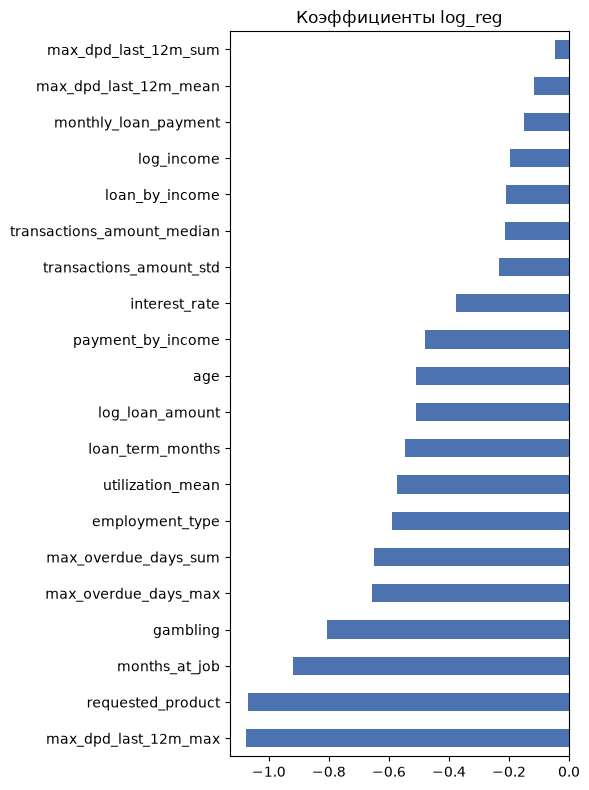

In [178]:
# коэффициенты log_reg по силе влияния
coefs = pd.Series(log_reg.coef_[0], index=features_top).sort_values()
coefs.plot(kind='barh', figsize=(6, 8), color='#4C72B0')
plt.title('Коэффициенты log_reg')
plt.tight_layout()
plt.show()

/opt/anaconda3/envs/study/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


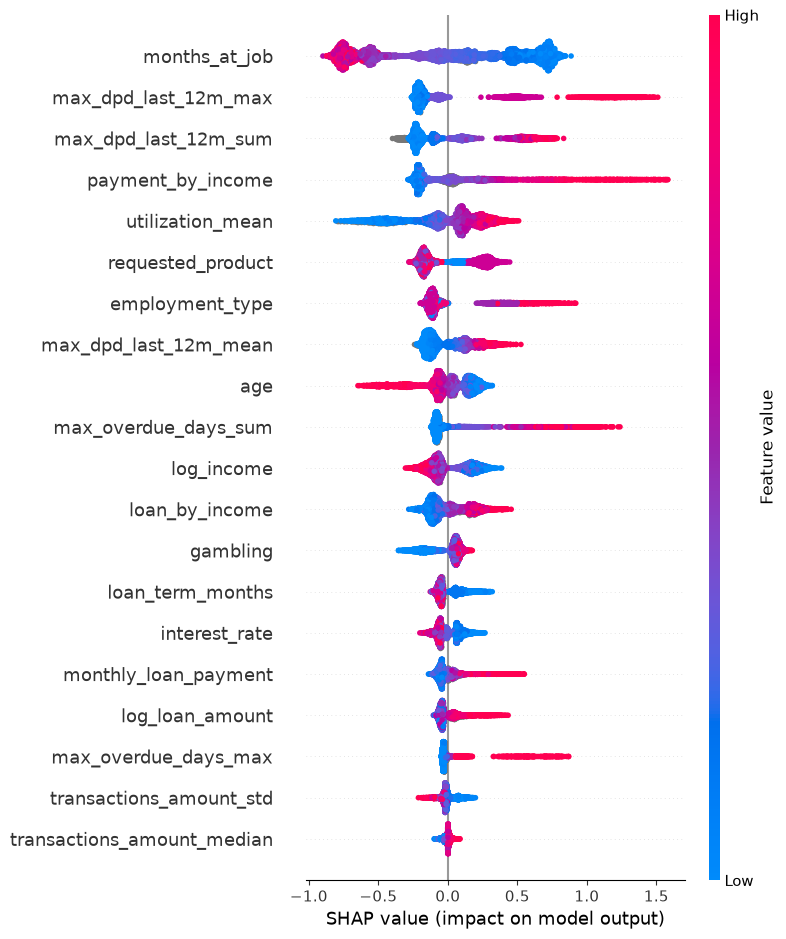

In [179]:
# важность признаков lgmm по shap
import shap

explainer = shap.TreeExplainer(lgmm)
shap_values = explainer.shap_values(X_train_raw[features_top])
shap.summary_plot(shap_values, X_train_raw[features_top])

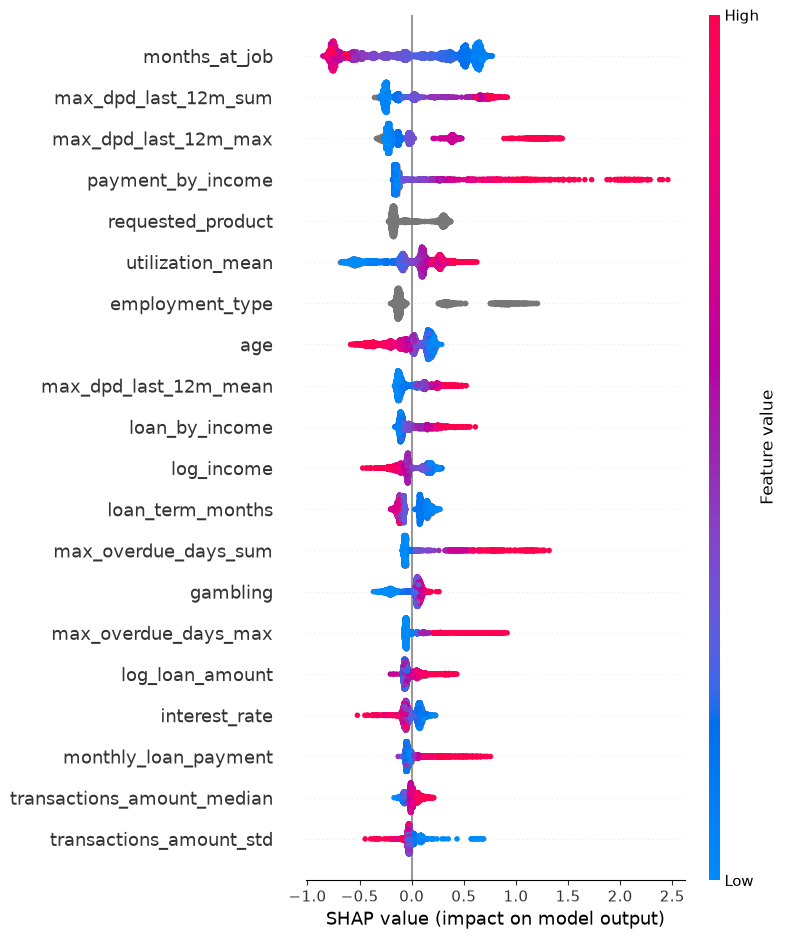

In [180]:
# важность признаков catboost по shap
import shap

explainer = shap.TreeExplainer(catboost)
shap_values = explainer.shap_values(X_train_cb[features_top])
shap.summary_plot(shap_values, X_train_cb[features_top])

In [181]:
# таблица важности признаков по IV
table['feature'][:20]

0           max_dpd_last_12m_max
1           max_dpd_last_12m_sum
2          max_dpd_last_12m_mean
3                  months_at_job
4              payment_by_income
5                 loan_by_income
6                employment_type
7                 loan_to_income
8                         income
9                     log_income
10                monthly_income
11               incoming_amount
12          monthly_loan_payment
13    transactions_amount_median
14                           age
15               utilization_max
16       bureau_account_id_count
17           current_balance_sum
18       transactions_amount_std
19              utilization_mean
Name: feature, dtype: str

В обоих топах важности совпадают `max_dpd_last_12m_max/sum/mean`, `months_at_job`, `loan_by_income`, `employment_type`, `log_income`, `age` - это надежные сильные признаки. 

`loan_term_months`, `requested_product`, `interest_rate`, `current_balance_mean`, `max_overdue_days_sum/max`, `current_balance_min`, `credit_limit_mean/min`, `was_overdue_mean` - по отдельности данные признаки слабее, но модель нашла для них дополнительную ценность, вероятно, за счет нелинейных взамойтиействий с другими признаками. 

`income`, `monthly_income`, `incoming_amount`, `income_per_person`, `transactions_amount_median`, `bureau_account_id_count`, `current_balance_sum`, `loan_amount`, `credit_limit_sum` - эти признаки есть в топ 20 по IV, но они выпали из топ 20 SHAP. Можно предположить, что эти признаки дублируют `log_income`, `log_loan_amount`, `credit_limit_mean` и становятся избыточнымми для модели

Интересно: `gambling` по IV бесполезен (0.0105), а в оценке модели SHAP он находится в топ 20 признаках. Это можно объяснить тем, что тесты ttest и IV оценивают  признаки в изоляции, lgmm нашло, что признак полезен в комбинации с другими признаками 

Модель в целом объясняется ожидаемо. Коэффициенты `log_reg` в
большинстве имеют правильный знак, чем безопаснее бин по woe,
тем ниже предсказанный риск. У части признаков (`credit_limit_`, `current_balance_`
и еще несколько) знак перевернут, но это объясняется мультиколлинеарностью внутри
этих семейств. Сами признаки при этом остались в топе важности
по SHAP.

SHAP по `lgmm` показывает, что главные драйверы риска платежная история
(`max_dpd_last_12m_*`), стаж на работе, долговая нагрузка (`loan_by_income`) и доход, это согласуется с бизнес-логикой кредитного скоринга. 

Итого: модель ведет себя предсказуемо и объяснимо, серьезных проблем интерпретируемость
не выявила. Единственная найденная слабость это избыточные коррелированные признаки, которые стоит можно удалить для более простой модели


# 7. Предсказание на test

Модели уже обучены, остается применить к test те же woe-правила и мета-модель.

In [182]:
# те же woe-правила, что были посчитаны на train, применяю к test
X_test_woe_top = pd.DataFrame({feat: transform_woe(test, feat, rules)
                               for feat, rules in woe_rules.items()}, index=test.index)

X_meta_test = np.column_stack([
    log_reg.predict_proba(X_test_woe_top)[:, 1],
    lgmm.predict_proba(X_test_raw[features_top])[:, 1],
    catboost.predict_proba(X_test_cb[features_top])[:, 1],
])
test_pred = meta_model.predict_proba(X_meta_test)[:, 1]

submission = pd.DataFrame({"application_id": test["application_id"], "target": test_pred})
submission.to_csv(ROOT / "submission.csv", index=False)
submission.head()

,application_id,target
0,102531,0.806351
1,107213,0.734819
2,100238,0.204784
3,104918,0.193768
4,106480,0.368865


In [183]:
# PSI сравнивает распределение скора между train и test
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e_frac = pd.Series(pd.cut(expected, edges)).value_counts(normalize=True, sort=False).replace(0, 1e-4)
    a_frac = pd.Series(pd.cut(actual, edges)).value_counts(normalize=True, sort=False).replace(0, 1e-4)
    return ((a_frac - e_frac) * np.log(a_frac / e_frac)).sum()

X_meta_train = np.column_stack([oof_log_reg, oof_lgmm, oof_catboost])
train_pred = meta_model.predict_proba(X_meta_train)[:, 1]   # честный OOF, та же формула, что и test_pred
print(f'PSI (train vs test): {psi(train_pred, test_pred):.4f}')

PSI (train vs test): 0.0088


Сдвига нет, распределение скора между train и test почти одинаковое